# **8. STT — Spatio-Temporal Transformer**

Nuestro modelo STT (Spatio-Temporal Transformer) aprende explícitamente cómo los departamentos se influyen mutuamente en la propagación del dengue mediante un `SpatialAttentionBlock` exclusivo que aplica `MultiheadAttention` sobre la dimensión de nodos $N$ —remodelando el tensor como $(B \times T, N, D)$ para que cada nodo atienda a todos los demás en cada paso temporal— y cuya salida es una matriz $N \times N$ que revela qué departamentos actúan como focos de difusión regional. El flujo completo procesa los datos en cinco etapas: el `ModalEncoder` proyecta linealmente cada stream (epidemiológico: 11 variables; climático: 18 rezagos de temperatura, humedad y precipitación) a una dimensión común $d_\text{model}$, añade codificación posicional sinusoidal y aplica un `TransformerEncoder` *norm-first* produciendo tensores $(B, T, N, D)$; el `SpatialAttentionBlock` captura dependencias inter-departamentales; el `AdaptiveLagModule` selecciona dinámicamente las semanas pasadas más relevantes vía Softmax sobre la ventana `max_lag`, colapsando la dimensión temporal a $(B, N, D)$; el `CrossModalAttention` fusiona ambos streams usando el contexto epidemiológico como $Q$ y el climático como $K$ y $V$; y finalmente una capa `nn.Linear(d_model, horizon)` produce las predicciones $(B, H, N)$ sobre la incidencia log1p.

```text
              [ Input Tensor: (B, T, N, Features) ]
                                |
              +----------------+----------------+
              |                                 |
      [ Epi Features ]                  [ Clim Features ]
              |                                 |
      Linear Projection                 Linear Projection
              |                                 |
    Positional Encoding               Positional Encoding
              |                                 |
    Transformer Encoder               Transformer Encoder
              |                                 |
  SpatialAttentionBlock             SpatialAttentionBlock       <- nuevo
    MHA sobre N nodos                 MHA sobre N nodos
              |                                 |
    Adaptive Lag Module               Adaptive Lag Module
              |                                 |
              +----------------+----------------+
                                |
                      Cross-Modal Attention
                         Q=epi · K,V=clim
                                |
                          Dropout & FC
                                |
                [ Output: (B, H, N) Predictions ]
```

El esquema de validación combina un **Nested Temporal CV** en el eje externo —tres outer folds con años de test 2022, 2023 y 2024— con un **Spatial-KFold** de cinco particiones en el eje interno, construidas agrupando los departamentos por K-Means sobre sus centroides UTM con `spatialkfold`; en cada iteración de tuning el fold espacial retenido nunca aparece en el entrenamiento, forzando generalización hacia regiones no observadas y sumando 15 iteraciones por trial de Optuna (TPE, 20 trials), que optimiza sobre `{window_size, learning_rate, batch_size, dropout, d_model, n_heads, n_layers, dim_ff, max_lag}`. La interpretabilidad se obtiene por tres vías: las *spatial attention heatmaps* por stream ($N \times N$) que cuantifican la influencia inter-departamental, la *cross-modal attention heatmap* que mapea cómo la señal climática de un departamento modula la predicción epidemiológica de otro, y `shap.GradientExplainer` sobre un wrapper que aplana la salida a $(B, H \times N)$ para derivar importancias globales de variables. El pipeline se ejecuta con tres semillas (`[42, 123, 2024]`) con determinismo completo, guardando pesos, predicciones desagregadas por departamento y horizonte, residuos, curvas de aprendizaje e importancias SHAP en `Modelos/STT_CV/`.

  

## **8.1. Librerías**

In [18]:
import os, copy, random, warnings, math, sys, time
import optuna
import shap
import numpy as np
import pandas as pd
import scipy.stats as st
import geopandas as gpd

from spatialkfold.clusters import spatial_kfold_clusters
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

## **8.2. Configuracion y Reproducibilidad**

Se establece el entorno y las configuraciones de reproducibilidad del proyecto, inicializando las semillas globales (`SEEDS`), el número de pliegues espaciales (`N_SPATIAL_FOLDS = 5`) y los intentos de optimización con Optuna.

In [19]:
SEEDS           = [42, 123, 2024]
N_SPATIAL_FOLDS = 5
N_OPTUNA_TRIALS = 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("medium")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Python:", sys.version)
print("Torch:",  torch.__version__)
print("Numpy:",  np.__version__)
print("Pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"  Seed fijada: {seed}")

g = torch.Generator()

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Python: 3.10.20 (main, Mar  3 2026, 09:24:47) [GCC 13.3.0]
Torch: 2.11.0+cu130
Numpy: 2.2.6
Pandas: 2.3.3
GeoPandas: 1.1.3


## **8.3. Carga de Datos y Feature Engineering**

Se inicializan las rutas del proyecto y se carga el conjunto de datos principal (`df_full.csv`), indexando la columna temporal en formato `datetime` para posteriormente ordenar de forma ascendente los registros por departamento y fecha, asegurando así la consistencia cronológica necesaria para el análisis de las series de tiempo.

In [20]:
from pathlib import Path

BASE_PATH = Path('Modelos/STT_CV')
BASE_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("Bases_Datos/df_full.csv")
df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"])
df = df.sort_values(["departamento", "fecha_inicio"]).reset_index(drop=True)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 21664 | Columnas: 54


,departamento,fecha_inicio,ano,semana,casos,casos_mujeres,casos_hombres,casos_rural,casos_urbano,(0_5],...,precip_lag_12,precip_lag_20,temp_c,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_4,temp_lag_8,temp_lag_12,temp_lag_20
0,Amazonas,2012-01-02,2012,1,0.0,0,0,0,0,0,...,50.983546,39.108242,24.848668,24.890654,24.334752,24.545618,25.345678,25.278160,25.874930,24.364443
1,Amazonas,2012-01-09,2012,2,0.0,0,0,0,0,0,...,61.818291,62.830250,24.729721,24.848668,24.890654,24.334752,24.545618,25.084141,25.495665,24.971798
2,Amazonas,2012-01-16,2012,3,0.0,0,0,0,0,0,...,24.950393,42.988018,24.638674,24.729721,24.848668,24.890654,24.334752,25.751070,25.760539,25.304947
3,Amazonas,2012-01-23,2012,4,0.0,0,0,0,0,0,...,88.169343,56.572467,25.164008,24.638674,24.729721,24.848668,24.890654,25.284157,25.842089,25.166142
4,Amazonas,2012-01-30,2012,5,0.0,0,0,0,0,0,...,56.271440,74.893047,24.604644,25.164008,24.638674,24.729721,24.848668,25.345678,25.278160,25.312395


En este bloque se realiza la ingeniería de características mapeando cíclicamente las semanas epidemiológicas mediante funciones seno y coseno para capturar la estacionalidad del dengue, definimos los conjuntos de variables predictoras epidemiológicas y climáticas con sus respectivos rezagos históricos, y aplicamos una transformación logarítmica (`log1p`) sobre la incidencia para mitigar el sesgo provocado por los picos extremos de los brotes.

In [21]:
df["semana"] = df["semana"].astype(int)
df["ano"]    = df["fecha_inicio"].dt.year

weeks_per_year  = df.groupby("ano")["semana"].transform("max")
df["week_norm"] = df["semana"] / weeks_per_year
df["week_sin"]  = np.sin(2 * np.pi * df["week_norm"])
df["week_cos"]  = np.cos(2 * np.pi * df["week_norm"])

EPIFEATURES = [
    "inc_lag_1","inc_lag_2","inc_lag_3","inc_lag_4",
    "inc_lag_8","inc_lag_12","inc_lag_20",
    "poblacion","prop_rural","week_sin","week_cos"
]
CLIMFEATURES = [
    "temp_lag_1","temp_lag_2","temp_lag_4","temp_lag_8","temp_lag_12","temp_lag_20",
    "humedad_lag_1","humedad_lag_2","humedad_lag_4","humedad_lag_8","humedad_lag_12","humedad_lag_20",
    "precip_lag_1","precip_lag_2","precip_lag_4","precip_lag_8","precip_lag_12","precip_lag_20",
]
FEATURES = EPIFEATURES + CLIMFEATURES

df["incidencia_log"] = np.log1p(df["incidencia"])
TARGET = "incidencia_log"
N_EPI  = len(EPIFEATURES)
N_CLIM = len(CLIMFEATURES)

print(f"EpiFeatures : {N_EPI}")
print(f"ClimFeatures: {N_CLIM}")
print(f"Total       : {len(FEATURES)} | Target: {TARGET}")

EpiFeatures : 11
ClimFeatures: 18
Total       : 29 | Target: incidencia_log


In [22]:
departments = sorted(df["departamento"].unique())
dept_to_idx = {d: i for i, d in enumerate(departments)}
idx_to_dept = {i: d for d, i in dept_to_idx.items()}
NUM_NODES   = len(departments)
print(f"NUM_NODES: {NUM_NODES}")
print("Departamentos:", departments)

NUM_NODES: 32
Departamentos: ['Amazonas', 'Antioquia', 'Arauca', 'Atlantico', 'Bogota d.c.', 'Bolivar', 'Boyaca', 'Caldas', 'Caqueta', 'Casanare', 'Cauca', 'Cesar', 'Choco', 'Cordoba', 'Cundinamarca', 'Guainia', 'Guajira', 'Guaviare', 'Huila', 'Magdalena', 'Meta', 'Narino', 'Norte De Santander', 'Putumayo', 'Quindio', 'Risaralda', 'Santander', 'Sucre', 'Tolima', 'Valle Del Cauca', 'Vaupes', 'Vichada']


## **8.4. Construccion de Folds Espaciales con spatial-kfold**

En este bloque se construyen los **folds espaciales** que estructuran la validación cruzada del modelo. A partir de un CSV con las coordenadas geográficas de cada departamento, se calcula el centroide promedio por entidad territorial y se construye un `GeoDataFrame` en proyección geográfica estándar (EPSG:4326) que luego se reproyecta a coordenadas UTM locales —usando `estimate_utm_crs()` para preservar distancias métricas reales— sobre las cuales `spatial_kfold_clusters` aplica K-Means con $k=5$ para agrupar los departamentos en cinco particiones geográficamente compactas y mutuamente excluyentes; la asignación resultante se mapea al dataframe principal mediante `fold_map`, añadiendo la columna `spatial_fold` a cada observación. Finalmente, se genera un mapa de dispersión que visualiza los cinco clusters sobre el territorio colombiano, anotando el nombre de cada departamento sobre su centroide, con el propósito de verificar visualmente que los folds respetan la contigüidad geográfica y que ningún fold concentra desproporcionadamente regiones epidemiológicamente similares —condición necesaria para que la validación espacial mida genuina capacidad de generalización hacia zonas no vistas durante el entrenamiento.

In [23]:
cent = pd.read_csv('Covariables/centroides_departamentos.csv')

dept_coords = (
    cent.groupby("departamento")
      .agg(lat=("latitud", "mean"), lon=("longitud", "mean"))
      .reset_index()
)

geometry   = gpd.points_from_xy(dept_coords["lon"], dept_coords["lat"])
gdf_depts  = gpd.GeoDataFrame(dept_coords, geometry=geometry, crs="EPSG:4326")
gdf_depts_utm = gdf_depts.to_crs(gdf_depts.estimate_utm_crs())

In [24]:
gdf_depts_folded = spatial_kfold_clusters(
    gdf=gdf_depts_utm,
    name="departamento",
    nfolds=N_SPATIAL_FOLDS,
    algorithm="kmeans",
    random_state=42
)
print("Columnas resultado:", gdf_depts_folded.columns.tolist())
print(gdf_depts_folded[["departamento","folds"]].sort_values("folds").to_string(index=False))

Columnas resultado: ['departamento', 'lat', 'lon', 'geometry', 'folds']
      departamento  folds
         Atlantico      1
           Bolivar      1
           Cordoba      1
             Cesar      1
             Sucre      1
Norte De Santander      1
         Magdalena      1
           Guajira      1
           Caqueta      2
             Huila      2
            Narino      2
          Putumayo      2
             Cauca      2
      Cundinamarca      3
       Bogota d.c.      3
         Antioquia      3
            Tolima      3
           Quindio      3
         Risaralda      3
         Santander      3
            Boyaca      3
            Caldas      3
             Choco      3
              Meta      3
   Valle Del Cauca      3
          Guaviare      4
            Vaupes      4
          Amazonas      4
           Guainia      5
          Casanare      5
            Arauca      5
           Vichada      5


In [25]:
fold_map = gdf_depts_folded.set_index("departamento")["folds"].to_dict()
df["spatial_fold"] = df["departamento"].map(fold_map)

print("Observaciones por fold espacial:")
print(df.groupby("spatial_fold")["departamento"].nunique().rename("n_departamentos"))
print("\nDepartamentos por fold:")
for fold_id, grp in df.groupby("spatial_fold")["departamento"].unique().items():
    print(f"  Fold {fold_id}: {sorted(grp)}")

Observaciones por fold espacial:
spatial_fold
1     8
2     5
3    12
4     3
5     4
Name: n_departamentos, dtype: int64

Departamentos por fold:
  Fold 1: ['Atlantico', 'Bolivar', 'Cesar', 'Cordoba', 'Guajira', 'Magdalena', 'Norte De Santander', 'Sucre']
  Fold 2: ['Caqueta', 'Cauca', 'Huila', 'Narino', 'Putumayo']
  Fold 3: ['Antioquia', 'Bogota d.c.', 'Boyaca', 'Caldas', 'Choco', 'Cundinamarca', 'Meta', 'Quindio', 'Risaralda', 'Santander', 'Tolima', 'Valle Del Cauca']
  Fold 4: ['Amazonas', 'Guaviare', 'Vaupes']
  Fold 5: ['Arauca', 'Casanare', 'Guainia', 'Vichada']


In [26]:
fig, ax = plt.subplots(figsize=(7, 9))
for fold_id in range(N_SPATIAL_FOLDS):
    sub = gdf_depts_folded[gdf_depts_folded["folds"] == fold_id]
    sub.plot(ax=ax, markersize=120, label=f"Fold {fold_id}")
    for _, row in sub.iterrows():
        ax.annotate(row["departamento"], xy=(row.geometry.x, row.geometry.y),
                    fontsize=5, ha="center", va="bottom")
ax.set_title(f"Folds espaciales KMeans (k={N_SPATIAL_FOLDS})", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_spatial_folds_map.png", dpi=150)
plt.show()

## **8.5. Esquema de Validacion Espacio-Temporal (Nested CV)**

Esta sección define la estrategia de validación cruzada anidada (*Nested Cross-Validation*) para evaluar el modelo bajo un enfoque espacio-temporal estricto y robusto. Mediante las funciones `create_outer_folds` y `create_inner_folds`, el código fragmenta cronológicamente los datos en bloques externos de prueba (años 2022 a 2024) y bloques internos de validación (años 2019 a 2021) para simular escenarios reales de predicción a futuro. Finalmente, integra el estimador `LeaveOneGroupOut` de scikit-learn, configurando un esquema donde cada ciclo de optimización (*tuning*) cruza estas ventanas de tiempo con las regiones geográficas previas, garantizando que el algoritmo sea evaluado aislando grupos espaciales completos para medir su capacidad de generalización en territorios no observados.

In [27]:
def create_outer_folds(df, date_col="fecha_inicio"):
    folds = []
    for test_year in [2022, 2023, 2024]:
        train_df = df[df[date_col].dt.year <  test_year].copy()
        test_df  = df[df[date_col].dt.year == test_year].copy()
        folds.append({"test_year": test_year, "train_df": train_df, "test_df": test_df})
    return folds

def create_inner_folds(train_df, val_years=[2019, 2020, 2021]):
    inner_folds = []
    for val_year in val_years:
        inner_train = train_df[train_df["fecha_inicio"].dt.year <  val_year].copy()
        inner_val   = train_df[train_df["fecha_inicio"].dt.year == val_year].copy()
        inner_folds.append({"val_year": val_year,
                             "inner_train": inner_train,
                             "inner_val":   inner_val})
    return inner_folds

outer_folds = create_outer_folds(df)
LOGO = LeaveOneGroupOut()

print(f"Outer folds temporales: {len(outer_folds)}")
print(f"Inner folds temporales: 3 (2019, 2020, 2021)")
print(f"Folds espaciales: {N_SPATIAL_FOLDS}")
print(f"Total iteraciones tuning por trial: {3 * N_SPATIAL_FOLDS}")

Outer folds temporales: 3
Inner folds temporales: 3 (2019, 2020, 2021)
Folds espaciales: 5
Total iteraciones tuning por trial: 15


## **8.6. Ventanas de Tiempo y Escalamiento**

Se reestructuran los datos en ventanas deslizantes tridimensionales y posteriormente se realiza una normalización estadística. La función `create_windows` utiliza tablas de pivote para transformar el DataFrame plano en tensores organizados por tiempo, nodos (departamentos) y características, generando secuencias históricas de entrenamiento (`window_size=12`) emparejadas con sus respectivos horizontes de predicción futura (`horizon=4`). Por otro lado, la función `scale_data` implementa un objeto `RobustScaler` que se ajusta exclusivamente con los datos de entrenamiento tras aplanar temporalmente las dimensiones, escalando las señales basándose en percentiles e rangos intercuartílicos para neutralizar el impacto de valores atípicos extremos antes de devolver los arreglos con su forma espacio-temporal original.

In [ ]:
def create_windows(df, features, target, window_size=12, horizon=4):
    pivot_features = []
    for feat in features:
        pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                               values=feat).sort_index()
        pivot_features.append(pivot.values)

    X_all = np.stack(pivot_features, axis=-1)  

    target_pivot = df.pivot_table(index="fecha_inicio", columns="departamento",
                                  values=target).sort_index()
    y_all  = target_pivot.values
    dates  = target_pivot.index.values

    X, y, base_dates = [], [], []
    for i in range(len(dates) - window_size - horizon + 1):
        X.append(X_all[i : i + window_size])
        y.append(y_all[i + window_size : i + window_size + horizon])
        base_dates.append(dates[i + window_size - 1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), np.array(base_dates)

def scale_data(X_train, X_val):
    scaler = RobustScaler()
    nf     = X_train.shape[-1]
    X_train_2d = X_train.reshape(-1, nf)
    scaler.fit(X_train_2d)
    X_train_sc = scaler.transform(X_train_2d).reshape(X_train.shape)
    X_val_sc   = scaler.transform(X_val.reshape(-1, nf)).reshape(X_val.shape)
    return X_train_sc, X_val_sc, scaler

## **8.7. Dataset, Early Stopping y Funciones de Entrenamiento**

Primero, implementa la clase contenedora `STTDataset` para castear los arreglos multidimensionales a tensores de punto flotante de 32 bits nativos de GPU, estructurando el acceso por lotes mediante el método `__getitem__`. Adicionalmente, se define la clase `EarlyStopping` como un mecanismo de regularización que rastrea la pérdida de validación para interrumpir el entrenamiento si no hay mejoras tras un umbral de paciencia determinado, y se encapsulan las funciones de optimización por época (`train_one_epoch` y `validate_one_epoch`), las cuales gestionan la transferencia asíncrona de datos al hardware, el cálculo de gradientes con retropropagación, y la técnica de *gradient clipping* para estabilizar los pesos de la red neuronal.

In [29]:
class STTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class EarlyStopping:
    def __init__(self, patience=20):
        self.patience  = patience
        self.best_loss = np.inf
        self.counter   = 0
        self.stop      = False
    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def train_one_epoch(model, dataloader, criterion, optimizer, device, n_epi, n_clim):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)
        optimizer.zero_grad()
        pred, _ = model(X_batch, n_epi, n_clim)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate_one_epoch(model, dataloader, criterion, device, n_epi, n_clim):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            pred, _ = model(X_batch, n_epi, n_clim)
            loss = criterion(pred, y_batch)
            total_loss += loss.item()
    return total_loss / len(dataloader)

## **8.8. Metricas**

Se consolida el módulo de evaluación estadística del proyecto sobre los arreglos aplanados de los valores reales y predichos. Más allá de los indicadores tradicionales de magnitud de error como RMSE y MAE, se integra coeficientes hidrológicos y ecológicos avanzados como la eficiencia de Nash-Sutcliffe (`nse`) y el índice de Kling-Gupta (`kge`) para diagnosticar sesgos estructurales y variabilidad en la serie de tiempo. Asimismo, incorpora métricas de estricto control epidemiológico como el `rmse_top10`, el cual aísla los registros que superan el percentil 90 con el fin de cuantificar de forma específica el desempeño del modelo frente a picos extremos y brotes epidémicos severos de dengue.

In [30]:
def mape(y_true, y_pred, eps=1.0):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def smape(y_true, y_pred, eps=1.0):
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + eps
    return np.mean(num / den) * 100

def nse(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-10)

def kge(y_true, y_pred):
    r     = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-10)
    beta  = np.mean(y_pred) / (np.mean(y_true) + 1e-10)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

def skill_score(y_true, y_pred):
    mse_model = mean_squared_error(y_true, y_pred)
    mse_naive = mean_squared_error(y_true, np.full_like(y_true, np.mean(y_true)))
    return 1 - mse_model / (mse_naive + 1e-10)

def rmse_top10(y_true, y_pred, q=0.90):
    threshold = np.quantile(y_true, q)
    mask = y_true >= threshold
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def pearson_r(y_true, y_pred):
    if np.std(y_true) < 1e-10 or np.std(y_pred) < 1e-10:
        return np.nan
    return np.corrcoef(y_true, y_pred)[0, 1]

def compute_all_metrics(y_true, y_pred, prefix=""):
    yt, yp = np.array(y_true).flatten(), np.array(y_pred).flatten()
    return {
        f"{prefix}RMSE":       np.sqrt(mean_squared_error(yt, yp)),
        f"{prefix}MAE":        mean_absolute_error(yt, yp),
        f"{prefix}MAPE":       mape(yt, yp),
        f"{prefix}sMAPE":      smape(yt, yp),
        f"{prefix}NSE":        nse(yt, yp),
        f"{prefix}KGE":        kge(yt, yp),
        f"{prefix}SkillScore": skill_score(yt, yp),
        f"{prefix}RMSE_top10": rmse_top10(yt, yp),
        f"{prefix}Pearson_r":  pearson_r(yt, yp),
        f"{prefix}Bias":       float(np.mean(yp - yt)),
    }

print("Metricas cargadas.")

Metricas cargadas.


## **8.9. Arquitectura STT — Spatio-Temporal Transformer**

Se define la arquitectura central del modelo `SpatioTemporalTransformer` mediante submódulos personalizados de PyTorch que codifican por separado las secuencias epidemiológicas y climáticas proyectándolas linealmente a una dimensión común $d_\text{model}$, agregándoles codificación posicional sinusoidal antes de procesarlas con bloques de transformadores *norm-first* nativos. Cada stream pasa adicionalmente por un `SpatialAttentionBlock` que remodela el tensor a $(B \times T, N, D)$ y aplica `MultiheadAttention` sobre la dimensión de nodos $N$, permitiendo que cada departamento atienda a todos los demás en cada paso temporal y retornando tanto la representación enriquecida $(B, T, N, D)$ como una matriz de pesos promediados $(B, N, N)$ interpretable como mapa de influencia inter-departamental. Posteriormente, la red aplana las dimensiones espacio-temporales para que los módulos de rezago adaptativo (`AdaptiveLagModule`) ponderen dinámicamente el historial de variables mediante productos tensoriales `torch.einsum`, fusionando ambos contextos con una capa de atención cruzada (`CrossModalAttention`) que usa el contexto epidemiológico como $Q$ y el climático como $K$ y $V$ antes de mapear el resultado hacia una capa lineal que proyecta el horizonte predictivo simultáneamente para todos los nodos, retornando además las tres matrices de atención —cross-modal, espacial epi y espacial clim— para su posterior análisis de interpretabilidad.

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class SpatialAttentionBlock(nn.Module):

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model debe ser divisible entre n_heads"
        self.mha     = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, N, D = x.shape
        x_flat = x.reshape(B * T, N, D)
        attn_out, attn_w = self.mha(x_flat, x_flat, x_flat)
        out = self.norm(x_flat + self.dropout(attn_out))
        out = out.reshape(B, T, N, D)          
        attn_w = attn_w.reshape(B, T, N, N).mean(dim=1)
        return out, attn_w


class AdaptiveLagModule(nn.Module):
    def __init__(self, d_model, max_lag=8):
        super().__init__()
        self.max_lag   = max_lag
        self.attn_proj = nn.Linear(d_model, 1)
    def forward(self, x):
        B, T, N, D = x.shape
        x_lag   = x[:, -self.max_lag:, :, :]
        scores  = self.attn_proj(x_lag).squeeze(-1).permute(0, 2, 1)
        weights = F.softmax(scores, dim=-1)
        x_perm  = x_lag.permute(0, 2, 1, 3)
        context = torch.einsum("bnl,bnld->bnd", weights, x_perm)
        return context, weights


class CrossModalAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.mha     = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, epi_ctx, clim_ctx):
        attn_out, attn_w = self.mha(epi_ctx, clim_ctx, clim_ctx)
        fused = self.norm(epi_ctx + self.dropout(attn_out))
        return fused, attn_w


class ModalEncoder(nn.Module):
    def __init__(self, in_features, d_model, n_heads, n_layers, dim_feedforward, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers,
                                              enable_nested_tensor=False)
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        return self.encoder(x)


class SpatioTemporalTransformer(nn.Module):
    def __init__(self, num_nodes, n_epi, n_clim,
                 d_model=64, n_heads=4, n_layers=2, dim_ff=128,
                 horizon=4, max_lag=8, dropout=0.1):
        super().__init__()
        self.num_nodes = num_nodes
        self.horizon   = horizon
        self.d_model   = d_model

        self.epi_encoder  = ModalEncoder(n_epi,  d_model, n_heads, n_layers, dim_ff, dropout)
        self.clim_encoder = ModalEncoder(n_clim, d_model, n_heads, n_layers, dim_ff, dropout)

        self.spatial_attn_epi  = SpatialAttentionBlock(d_model, n_heads, dropout)
        self.spatial_attn_clim = SpatialAttentionBlock(d_model, n_heads, dropout)

        self.lag_epi  = AdaptiveLagModule(d_model, max_lag=max_lag)
        self.lag_clim = AdaptiveLagModule(d_model, max_lag=max_lag)

        self.cross_attn = CrossModalAttention(d_model, n_heads, dropout)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(d_model, horizon)

    def forward(self, x, n_epi, n_clim):
        B, T, N, _ = x.shape

        X_epi  = x[:, :, :, :n_epi]
        X_clim = x[:, :, :, n_epi:n_epi + n_clim]

        X_epi_flat  = X_epi.permute(0, 2, 1, 3).reshape(B * N, T, n_epi)
        epi_enc     = self.epi_encoder(X_epi_flat)
        epi_enc     = epi_enc.reshape(B, N, T, self.d_model).permute(0, 2, 1, 3)  

        X_clim_flat = X_clim.permute(0, 2, 1, 3).reshape(B * N, T, n_clim)
        clim_enc    = self.clim_encoder(X_clim_flat)
        clim_enc    = clim_enc.reshape(B, N, T, self.d_model).permute(0, 2, 1, 3)  

        epi_sp,  sp_w_epi  = self.spatial_attn_epi(epi_enc)    
        clim_sp, sp_w_clim = self.spatial_attn_clim(clim_enc)  

        epi_ctx,  _      = self.lag_epi(epi_sp)    
        clim_ctx, _      = self.lag_clim(clim_sp)  

        fused, attn_cross = self.cross_attn(epi_ctx, clim_ctx)  

        out = self.fc(self.dropout(fused)).permute(0, 2, 1) 
        return out, (attn_cross, sp_w_epi, sp_w_clim)

print("Arquitectura STT definida.")

Arquitectura STT definida.


## **8.10. Optimizacion de Hiperparametros (Optuna + Spatial-KFold x Inner Temporal)**

Aquí se define la función objetivo de Optuna para automatizar la optimización de hiperparámetros estructurales y de entrenamiento del transformador mediante un esquema de validación cruzada anidada. Para cada combinación de parámetros propuesta por el muestreador TPE, se ejecuta un bucle doble que cruza los tres folds temporales internos (años 2019, 2020 y 2021) con los cinco pliegues geográficos construidos por K-Means, reteniendo en cada iteración un fold espacial completo como conjunto de validación y entrenando el modelo únicamente con los departamentos restantes; los trials que producen configuraciones inválidas —donde `d_model` no es divisible entre `n_heads` o `dim_ff` es menor que `d_model`— se podan anticipadamente con `TrialPruned` para evitar evaluaciones innecesarias. Al finalizar las 15 iteraciones, se calcula el RMSE promedio como señal de retorno a Optuna y se registran tanto los resultados por fold espacial como los parámetros del trial en las listas globales, asegurando una selección de hiperparámetros robusta frente al doble sesgo espacio-temporal.

In [32]:
ALL_OPTUNA_TRIALS    = []
ALL_SPATIAL_CV_FOLDS = []
ALL_RESIDUALS        = []
ALL_INFERENCE_TIME   = []
ALL_BEST_PARAMS      = []
ALL_RESULTS          = []
ALL_PREDICTIONS      = []
ALL_LOSSES           = []
ALL_SPATIAL_RESULTS  = []

BASE_PATH = str(BASE_PATH)
os.makedirs(BASE_PATH, exist_ok=True)

TUNING_DF          = df[df["fecha_inicio"].dt.year < 2022].copy()
INNER_FOLDS_TUNING = create_inner_folds(TUNING_DF, val_years=[2019, 2020, 2021])

print(f"Iteraciones por trial Optuna: {len(INNER_FOLDS_TUNING)} temporal x {N_SPATIAL_FOLDS} espacial = "
      f"{len(INNER_FOLDS_TUNING) * N_SPATIAL_FOLDS}")

Iteraciones por trial Optuna: 3 temporal x 5 espacial = 15


In [33]:
current_seed = None

def objective(trial):
    window_size   = trial.suggest_categorical("window_size",   [8, 12, 16])
    learning_rate = trial.suggest_float(      "learning_rate", 5e-4, 5e-3, log=True)
    batch_size    = trial.suggest_categorical("batch_size",    [16, 32])
    dropout       = trial.suggest_float(      "dropout",       0.0, 0.3, step=0.1)
    d_model       = trial.suggest_categorical("d_model",       [32, 64, 128])
    n_heads       = trial.suggest_categorical("n_heads",       [2, 4, 8])
    n_layers      = trial.suggest_int(        "n_layers",      1, 3)
    dim_ff        = trial.suggest_categorical("dim_ff",        [64, 128, 256])
    max_lag       = trial.suggest_int(        "max_lag",       2, 8)

    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()
    if dim_ff < d_model:
        raise optuna.exceptions.TrialPruned()

    rmse_all = []

    for inner_fold in INNER_FOLDS_TUNING:
        val_year    = inner_fold["val_year"]
        inner_train = inner_fold["inner_train"]
        inner_val   = inner_fold["inner_val"]

        dept_groups = inner_train.drop_duplicates("departamento")[["departamento","spatial_fold"]]

        for held_fold_id in range(N_SPATIAL_FOLDS):
            train_depts_sp = dept_groups[dept_groups["spatial_fold"] != held_fold_id]["departamento"].tolist()
            val_depts_sp   = dept_groups[dept_groups["spatial_fold"] == held_fold_id]["departamento"].tolist()

            if not train_depts_sp or not val_depts_sp:
                continue

            sp_train = inner_train[inner_train["departamento"].isin(train_depts_sp)].copy()
            sp_val   = inner_val[  inner_val[  "departamento"].isin(val_depts_sp)  ].copy()

            if len(sp_train) == 0 or len(sp_val) == 0:
                continue

            try:
                X_train, y_train, _ = create_windows(sp_train, FEATURES, TARGET, window_size, 4)
                X_val,   y_val,   _ = create_windows(sp_val,   FEATURES, TARGET, window_size, 4)
            except Exception:
                continue

            if len(X_train) == 0 or len(X_val) == 0:
                continue

            X_train_sc, X_val_sc, _ = scale_data(X_train, X_val)
            n_nodes_train = X_train_sc.shape[2]

            train_loader = DataLoader(
                STTDataset(X_train_sc, y_train), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )
            val_loader = DataLoader(
                STTDataset(X_val_sc, y_val), batch_size=batch_size,
                shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True
            )

            model = SpatioTemporalTransformer(
                num_nodes=n_nodes_train, n_epi=N_EPI, n_clim=N_CLIM,
                d_model=d_model, n_heads=n_heads, n_layers=n_layers,
                dim_ff=dim_ff, horizon=4, max_lag=max_lag, dropout=dropout
            ).to(DEVICE)

            criterion      = nn.MSELoss()
            optimizer      = torch.optim.Adam(model.parameters(), lr=learning_rate)
            early_stopping = EarlyStopping(patience=10)

            for epoch in range(50):
                train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, N_EPI, N_CLIM)
                vl = validate_one_epoch(model, val_loader, criterion, DEVICE, N_EPI, N_CLIM)
                early_stopping.step(vl)
                if early_stopping.stop:
                    break

            model.eval()
            preds_list, trues_list = [], []
            with torch.no_grad():
                for Xb, yb in val_loader:
                    pred, _ = model(Xb.to(DEVICE), N_EPI, N_CLIM)
                    preds_list.append(pred.cpu().numpy())
                    trues_list.append(yb.numpy())

            p    = np.concatenate(preds_list).flatten()
            t    = np.concatenate(trues_list).flatten()
            rmse = np.sqrt(mean_squared_error(t, p))
            rmse_all.append(rmse)

            ALL_SPATIAL_CV_FOLDS.append({
                "trial": trial.number, "seed": current_seed,
                "val_year": val_year, "held_spatial_fold": held_fold_id,
                "held_depts": str(val_depts_sp), "rmse": rmse
            })

    if not rmse_all:
        raise optuna.exceptions.TrialPruned()

    rmse_mean = float(np.mean(rmse_all))
    rmse_std  = float(np.std(rmse_all))

    ALL_OPTUNA_TRIALS.append({
        "trial": trial.number, "seed": current_seed,
        "window_size": window_size, "learning_rate": learning_rate,
        "batch_size": batch_size, "dropout": dropout,
        "d_model": d_model, "n_heads": n_heads,
        "n_layers": n_layers, "dim_ff": dim_ff, "max_lag": max_lag,
        "rmse_mean": rmse_mean, "rmse_std": rmse_std
    })

    trial.set_user_attr("rmse_folds", rmse_all)
    trial.set_user_attr("rmse_std",   rmse_std)
    return rmse_mean

print("Funcion objetivo Optuna + Spatial-KFold definida.")

Funcion objetivo Optuna + Spatial-KFold definida.


## **8.11. Pipeline Principal — Train, Spatial-KFold en Test y Evaluacion**

Esta sección consolida el ciclo principal de experimentación distribuyendo el flujo en un bucle iterativo multisemilla (`SEEDS`) que acopla la optimización de hiperparámetros con la evaluación final del modelo. Para cada semilla, la celda ejecuta el ajuste óptimo mediante `TPESampler` de Optuna, luego entrena la red neuronal a lo largo de los tres outer folds temporales —años de test 2022, 2023 y 2024— incorporando un planificador de tasa de aprendizaje `ReduceLROnPlateau` y preservando en todo momento el estado del mejor modelo vía `deepcopy` antes de persistirlo en disco, y finalmente efectúa la inferencia en la escala original (`expm1`) para extraer métricas de rendimiento globales y desagregadas por cada pliegue geográfico, validando de forma rigurosa la capacidad de generalización del transformador ante dinámicas epidemiológicas espaciales no observadas durante el entrenamiento.

In [ ]:
for seed in SEEDS:
    print("\n" + "="*110)
    print(f"  SEED {seed}")
    print("="*110)

    set_seed(seed)
    current_seed = seed

    print("\n[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparametros...")
    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_trial.params
    print(f"  Mejores hiperparametros (seed {seed}):")
    for k, v in best_params.items():
        print(f"    {k}: {v}")

    pd.DataFrame([{"seed": seed, **best_params}]).to_csv(
        f"{BASE_PATH}/stt_best_params_seed_{seed}.csv", index=False)
    ALL_BEST_PARAMS.append({"seed": seed, **best_params})

    for outer_idx, outer_fold in enumerate(outer_folds):
        test_year = outer_fold["test_year"]
        print(f"\n{'='*110}")
        print(f"  [OUTER FOLD {outer_idx+1}/3]  Test year: {test_year}  |  Seed: {seed}")
        print(f"{'='*110}")

        outer_train_df = outer_fold["train_df"]
        final_test_df  = outer_fold["test_df"]

        window_size   = best_params["window_size"]
        d_model       = best_params["d_model"]
        n_heads       = best_params["n_heads"]
        n_layers      = best_params["n_layers"]
        dim_ff        = best_params["dim_ff"]
        max_lag       = best_params["max_lag"]
        dropout       = best_params["dropout"]
        learning_rate = best_params["learning_rate"]
        batch_size    = best_params["batch_size"]

        val_year       = outer_train_df["fecha_inicio"].dt.year.max()
        final_train_df = outer_train_df[outer_train_df["fecha_inicio"].dt.year <  val_year]
        final_val_df   = outer_train_df[outer_train_df["fecha_inicio"].dt.year == val_year]

        print(f"  Entrenamiento: hasta {val_year-1} | Val: {val_year} | Test: {test_year}")

        X_train, y_train, train_dates = create_windows(final_train_df, FEATURES, TARGET, window_size, 4)
        X_val,   y_val,   val_dates   = create_windows(final_val_df,   FEATURES, TARGET, window_size, 4)
        X_test,  y_test,  test_dates  = create_windows(final_test_df,  FEATURES, TARGET, window_size, 4)

        X_train_sc, X_val_sc, scaler = scale_data(X_train, X_val)
        X_test_sc = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

        print(f"  Shapes — Train: {X_train_sc.shape} | Val: {X_val_sc.shape} | Test: {X_test_sc.shape}")

        train_loader = DataLoader(STTDataset(X_train_sc, y_train), batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(STTDataset(X_val_sc,   y_val),   batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
        test_loader  = DataLoader(STTDataset(X_test_sc,  y_test),  batch_size=batch_size,
                                  shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

        model = SpatioTemporalTransformer(
            num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
            d_model=d_model, n_heads=n_heads, n_layers=n_layers,
            dim_ff=dim_ff, horizon=4, max_lag=max_lag, dropout=dropout
        ).to(DEVICE)

        criterion        = nn.MSELoss()
        optimizer        = torch.optim.Adam(model.parameters(), lr=learning_rate)
        scheduler        = torch.optim.lr_scheduler.ReduceLROnPlateau(
                               optimizer, mode="min", factor=0.5, patience=10)
        early_stopping   = EarlyStopping(patience=20)
        best_model_state = None
        best_loss        = np.inf
        total_train_time = 0.0

        print(f"\n  Entrenando STT (max 300 epocas, early stopping patience=20)...")
        print(f"  {'Epoca':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'ES Counter':>10}")
        print(f"  {'-'*55}")

        for epoch in range(300):
            t0         = time.time()
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, N_EPI, N_CLIM)
            val_loss   = validate_one_epoch(model, val_loader, criterion, DEVICE, N_EPI, N_CLIM)
            scheduler.step(val_loss)
            total_train_time += time.time() - t0

            if epoch % 10 == 0 or epoch < 5:
                print(f"  {epoch+1:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | "
                      f"{early_stopping.counter:>10}/{early_stopping.patience}")

            ALL_LOSSES.append({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "epoch": epoch+1, "train_loss": train_loss, "val_loss": val_loss
            })

            if val_loss < best_loss:
                best_loss        = val_loss
                best_model_state = copy.deepcopy(model.state_dict())

            early_stopping.step(val_loss)
            if early_stopping.stop:
                print(f"  Early stopping en epoca {epoch+1} (best val_loss={best_loss:.6f})")
                break

        model.load_state_dict(best_model_state)
        print(f"  Entrenamiento completado — {total_train_time:.1f}s totales")

        torch.save(model.state_dict(),
                   f"{BASE_PATH}/stt_seed_{seed}_outer_fold_{outer_idx+1}.pt")

        model.eval()
        t_inf = time.time()
        predictions, targets, attn_list = [], [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred, attn_tuple = model(Xb.to(DEVICE), N_EPI, N_CLIM)
                predictions.append(pred.cpu().numpy())
                targets.append(yb.numpy())
                attn_list.append(attn_tuple[0].cpu().numpy())
        inference_time = time.time() - t_inf

        predictions = np.concatenate(predictions)   
        targets     = np.concatenate(targets)
        pred_real   = np.expm1(predictions)
        true_real   = np.expm1(targets)

        m_real = compute_all_metrics(true_real, pred_real, prefix="real_")
        m_log  = compute_all_metrics(targets, predictions, prefix="log_")

        ALL_RESULTS.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "train_time": total_train_time, "inference_time": inference_time,
            **m_real, **m_log
        })
        ALL_INFERENCE_TIME.append({
            "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
            "inference_time": inference_time, "train_time": total_train_time
        })

        print(f"\n  [METRICAS GLOBALES TEST — escala real]")
        for k, v in m_real.items():
            print(f"    {k}: {v:.4f}")

        rows_pred = []
        for i in range(len(predictions)):
            for h in range(4):
                for node in range(NUM_NODES):
                    yt  = float(targets[i, h, node])
                    yp  = float(predictions[i, h, node])
                    ytr = float(true_real[i, h, node])
                    ypr = float(pred_real[i, h, node])
                    res = yt - yp
                    dept_name = idx_to_dept[node]
                    rows_pred.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "y_true_log": yt, "y_pred_log": yp,
                        "y_true_real": ytr, "y_pred_real": ypr,
                        "residual": res, "abs_error": abs(res), "sq_error": res**2
                    })
                    ALL_RESIDUALS.append({
                        "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                        "departamento": dept_name,
                        "spatial_fold": fold_map[dept_name],
                        "fecha_base": test_dates[i], "horizonte": h+1,
                        "residual": res
                    })

        fold_pred_df = pd.DataFrame(rows_pred)
        ALL_PREDICTIONS.append(fold_pred_df)

        print(f"\n  [SPATIAL-KFOLD EN TEST] Metricas por fold espacial...")
        print(f"  {'Fold':>5} | {'Departamentos':40} | {'RMSE':>8} | {'MAE':>8} | "
              f"{'NSE':>8} | {'KGE':>8} | {'Pearson':>8}")
        print(f"  {'-'*100}")

        for sp_fold_id in range(N_SPATIAL_FOLDS):
            fold_dept_preds = fold_pred_df[fold_pred_df["spatial_fold"] == sp_fold_id]
            if len(fold_dept_preds) < 2:
                continue

            yt_sp = fold_dept_preds["y_true_real"].values
            yp_sp = fold_dept_preds["y_pred_real"].values
            m_sp  = compute_all_metrics(yt_sp, yp_sp)

            depts_in_fold = sorted(fold_dept_preds["departamento"].unique())
            depts_str     = ", ".join(depts_in_fold[:3])
            if len(depts_in_fold) > 3:
                depts_str += f" (+{len(depts_in_fold)-3})"

            m_sp.update({
                "seed": seed, "outer_fold": outer_idx+1, "test_year": test_year,
                "spatial_fold": sp_fold_id,
                "n_departamentos": len(depts_in_fold),
                "departamentos": str(depts_in_fold)
            })
            ALL_SPATIAL_RESULTS.append(m_sp)

            print(f"  {sp_fold_id:>5} | {depts_str:40} | {m_sp['RMSE']:>8.3f} | "
                  f"{m_sp['MAE']:>8.3f} | {m_sp['NSE']:>8.3f} | "
                  f"{m_sp['KGE']:>8.3f} | {m_sp['Pearson_r']:>8.3f}")


  SEED 42
  Seed fijada: 42

[PASO 1] Optuna + Spatial-KFold — buscando mejores hiperparametros...


  0%|          | 0/20 [00:00<?, ?it/s]

  Mejores hiperparametros (seed 42):
    window_size: 8
    learning_rate: 0.0007097909088756151
    batch_size: 32
    dropout: 0.2
    d_model: 32
    n_heads: 2
    n_layers: 2
    dim_ff: 128
    max_lag: 3

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 42
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (459, 8, 32, 29) | Val: (41, 8, 32, 29) | Test: (41, 8, 32, 29)

  Entrenando STT (max 300 epocas, early stopping patience=20)...
   Epoca |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.873482 |     0.315915 |          0/20
       2 |     0.427461 |     0.195608 |          0/20
       3 |     0.342737 |     0.183056 |          0/20
       4 |     0.310090 |     0.157285 |          0/20
       5 |     0.285947 |     0.145068 |          0/20
      11 |     0.227247 |     0.124923 |          1/20
      21 |     0.180994 |     0.104969 |          0/20
      31 |     0.164896 |     0.102820 |   

  0%|          | 0/20 [00:00<?, ?it/s]

  Mejores hiperparametros (seed 123):
    window_size: 8
    learning_rate: 0.0005273541426900302
    batch_size: 16
    dropout: 0.2
    d_model: 32
    n_heads: 8
    n_layers: 3
    dim_ff: 256
    max_lag: 3

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 123
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (459, 8, 32, 29) | Val: (41, 8, 32, 29) | Test: (41, 8, 32, 29)

  Entrenando STT (max 300 epocas, early stopping patience=20)...
   Epoca |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.712284 |     0.349952 |          0/20
       2 |     0.444340 |     0.199783 |          0/20
       3 |     0.342257 |     0.157532 |          0/20
       4 |     0.312138 |     0.145404 |          0/20
       5 |     0.287591 |     0.142470 |          0/20
      11 |     0.225758 |     0.135641 |          0/20
      21 |     0.185268 |     0.114934 |          0/20
      31 |     0.167834 |     0.107801 | 

  0%|          | 0/20 [00:00<?, ?it/s]

  Mejores hiperparametros (seed 2024):
    window_size: 12
    learning_rate: 0.0016581074642144887
    batch_size: 32
    dropout: 0.3
    d_model: 32
    n_heads: 4
    n_layers: 2
    dim_ff: 256
    max_lag: 3

  [OUTER FOLD 1/3]  Test year: 2022  |  Seed: 2024
  Entrenamiento: hasta 2020 | Val: 2021 | Test: 2022
  Shapes — Train: (455, 12, 32, 29) | Val: (37, 12, 32, 29) | Test: (37, 12, 32, 29)

  Entrenando STT (max 300 epocas, early stopping patience=20)...
   Epoca |   Train Loss |     Val Loss | ES Counter
  -------------------------------------------------------
       1 |     0.902451 |     0.501359 |          0/20
       2 |     0.612739 |     0.328343 |          0/20
       3 |     0.425915 |     0.229337 |          0/20
       4 |     0.341542 |     0.170228 |          0/20
       5 |     0.303395 |     0.160238 |          0/20
      11 |     0.219514 |     0.138694 |          0/20
      21 |     0.174614 |     0.109492 |          0/20
      31 |     0.165365 |     0.109

## **8.12. Guardado de Resultados**

Se consolida toda la metadata, métricas e inferencias generadas durante el pipeline de experimentación mediante la conversión de las listas globales estructuradas en estructuras de datos de pandas. Al exportar estos registros a archivos individuales en formato CSV, la celda asegura la trazabilidad y reproducibilidad del estudio, almacenando de forma organizada desde el historial de pérdidas de entrenamiento y los hiperparámetros óptimos seleccionados por Optuna, hasta las predicciones puntuales, los tiempos de cómputo y los residuos desagregados por departamento para su posterior análisis o auditoría estadística.

In [19]:
results_df          = pd.DataFrame(ALL_RESULTS)
predictions_df      = pd.concat(ALL_PREDICTIONS, axis=0).reset_index(drop=True)
losses_df           = pd.DataFrame(ALL_LOSSES)
best_params_df      = pd.DataFrame(ALL_BEST_PARAMS)
optuna_trials_df    = pd.DataFrame(ALL_OPTUNA_TRIALS)
spatial_cv_folds_df = pd.DataFrame(ALL_SPATIAL_CV_FOLDS)
inference_df        = pd.DataFrame(ALL_INFERENCE_TIME)
residuals_df        = pd.DataFrame(ALL_RESIDUALS)
spatial_results_df  = pd.DataFrame(ALL_SPATIAL_RESULTS)

results_df.to_csv(         f"{BASE_PATH}/stt_results.csv",              index=False)
predictions_df.to_csv(     f"{BASE_PATH}/stt_predictions.csv",          index=False)
losses_df.to_csv(          f"{BASE_PATH}/stt_training_history.csv",     index=False)
best_params_df.to_csv(     f"{BASE_PATH}/stt_best_params.csv",          index=False)
optuna_trials_df.to_csv(   f"{BASE_PATH}/stt_optuna_trials.csv",        index=False)
spatial_cv_folds_df.to_csv(f"{BASE_PATH}/stt_spatial_cv_folds.csv",     index=False)
inference_df.to_csv(       f"{BASE_PATH}/stt_inference_time.csv",       index=False)
residuals_df.to_csv(       f"{BASE_PATH}/stt_residuals.csv",            index=False)
spatial_results_df.to_csv( f"{BASE_PATH}/stt_spatial_fold_results.csv", index=False)

print("Archivos guardados en:", BASE_PATH)
print("\nResumen global:")
cols_show = [c for c in results_df.columns if c.startswith("real_")]
print(results_df[["seed","test_year"] + cols_show].to_string(index=False))

Archivos guardados en: Modelos/STT_CV

Resumen global:
 seed  test_year  real_RMSE  real_MAE  real_MAPE  real_sMAPE  real_NSE  real_KGE  real_SkillScore  real_RMSE_top10  real_Pearson_r  real_Bias
   42       2022   2.539391  1.129029  25.496622   23.265856  0.700019  0.640578         0.700019         7.189457        0.856227  -0.362348
   42       2023   3.657845  1.797873  28.009626   26.787025  0.656807  0.611393         0.656807        10.182247        0.834898  -0.919908
   42       2024   6.421500  3.525405  31.575085   30.724234  0.590947  0.472175         0.590947        17.639866        0.866815  -2.654454
  123       2022   2.529475  1.130075  26.448458   23.776201  0.702357  0.640268         0.702357         7.114069        0.858513  -0.310810
  123       2023   3.677381  1.795620  29.916847   26.824593  0.653131  0.605993         0.653131        10.269962        0.831246  -0.686422
  123       2024   5.515984  3.158470  31.936651   29.532423  0.698177  0.651598         0.69

## **8.13. Evaluacion — Carga de Resultados**

Se cargan desde el almacenamiento local los archivos CSV que contienen las métricas de rendimiento, las series de predicciones temporales y el historial de entrenamiento guardados previamente. 

In [34]:
BASE_PATH          = "Modelos/STT_CV"
results_df         = pd.read_csv(f"{BASE_PATH}/stt_results.csv")
predictions_df     = pd.read_csv(f"{BASE_PATH}/stt_predictions.csv")
residuals_df       = pd.read_csv(f"{BASE_PATH}/stt_residuals.csv")
losses_df          = pd.read_csv(f"{BASE_PATH}/stt_training_history.csv")
spatial_results_df = pd.read_csv(f"{BASE_PATH}/stt_spatial_fold_results.csv")
print("Datos cargados.")
print("  results_df shape:",         results_df.shape)
print("  predictions_df shape:",     predictions_df.shape)
print("  spatial_results_df shape:", spatial_results_df.shape)

Datos cargados.
  results_df shape: (9, 25)
  predictions_df shape: (45312, 14)
  spatial_results_df shape: (36, 16)


### **8.13.1. Metricas Globales y por Fold Espacial**

In [35]:
from PIL import Image

In [36]:
metric_cols_real = [c for c in results_df.columns if c.startswith("real_")]
metric_cols_log  = [c for c in results_df.columns if c.startswith("log_")]

print("=== METRICAS GLOBALES (Media +/- STD sobre seeds) ===")
for col in metric_cols_real:
    vals = results_df[col].dropna().values
    if len(vals) < 2: continue
    m   = np.mean(vals)
    sem = st.sem(vals)
    ci  = st.t.interval(0.95, df=len(vals)-1, loc=m, scale=sem)
    print(f"  {col:25}: {m:.4f} +/- {np.std(vals):.4f}  IC95%: [{ci[0]:.4f}, {ci[1]:.4f}]")

=== METRICAS GLOBALES (Media +/- STD sobre seeds) ===
  real_RMSE                : 4.1482 +/- 1.5796  IC95%: [2.8603, 5.4360]
  real_MAE                 : 2.1532 +/- 1.0431  IC95%: [1.3028, 3.0037]
  real_MAPE                : 28.8091 +/- 3.4008  IC95%: [26.0364, 31.5818]
  real_sMAPE               : 27.5132 +/- 4.3658  IC95%: [23.9538, 31.0726]
  real_NSE                 : 0.6480 +/- 0.0622  IC95%: [0.5973, 0.6987]
  real_KGE                 : 0.5711 +/- 0.0841  IC95%: [0.5025, 0.6396]
  real_SkillScore          : 0.6480 +/- 0.0622  IC95%: [0.5973, 0.6987]
  real_RMSE_top10          : 11.4159 +/- 4.1167  IC95%: [8.0596, 14.7722]
  real_Pearson_r           : 0.8544 +/- 0.0160  IC95%: [0.8413, 0.8675]
  real_Bias                : -1.2821 +/- 1.0466  IC95%: [-2.1354, -0.4288]


El STT alcanza un RMSE global de 4.15 ± 1.58 casos por 100.000 habitantes con un MAE de 2.15 ± 1.04, errores porcentuales del 28.8% (MAPE) y 27.5% (sMAPE) que reflejan dificultad moderada en semanas de baja incidencia, y una correlación de Pearson de 0.854 ± 0.016 que evidencia alta capacidad para reproducir la dinámica temporal de la enfermedad. El NSE y SkillScore de 0.648 indican que el modelo explica aproximadamente el 65% de la varianza observada superando con claridad al predictor naïve de media constante, mientras que el KGE de 0.571 sugiere que, aunque la correlación temporal es sólida, persisten desajustes en la variabilidad y la magnitud de las predicciones. El bias negativo de −1.28 ± 1.05 revela una tendencia sistemática a subestimar la incidencia real, y el RMSE_top10 de 11.42 ± 4.12 —casi tres veces el RMSE global— señala que el modelo pierde precisión de forma notable en las semanas de mayor carga epidémica, que son precisamente las más relevantes desde el punto de vista de la vigilancia en salud pública.

In [37]:
print("\n=== METRICAS POR FOLD ESPACIAL ===")
sp_summary = (
    spatial_results_df
    .groupby("spatial_fold")[["RMSE","MAE","NSE","KGE","SkillScore","Pearson_r","Bias"]]
    .agg(["mean","std"])
)
print(sp_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sp_rmse     = spatial_results_df.groupby("spatial_fold")["RMSE"].mean()
sp_rmse_std = spatial_results_df.groupby("spatial_fold")["RMSE"].std()
axes[0].bar(sp_rmse.index, sp_rmse.values, yerr=sp_rmse_std.values,
            color="steelblue", alpha=0.8, capsize=5)
axes[0].set_xlabel("Fold espacial (spatial-kfold)")
axes[0].set_ylabel("RMSE (escala real)")
axes[0].set_title("STT — RMSE por fold espacial", fontweight="bold")
axes[0].axhline(spatial_results_df["RMSE"].mean(), color="red", linestyle="--",
                label=f"Media global: {spatial_results_df['RMSE'].mean():.3f}")
axes[0].legend()

sp_bias = spatial_results_df.groupby("spatial_fold")["Bias"].mean()
colors_bias = ["tomato" if b > 0 else "steelblue" for b in sp_bias.values]
axes[1].bar(sp_bias.index, sp_bias.values, color=colors_bias, alpha=0.8)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Fold espacial")
axes[1].set_ylabel("Bias medio (pred - real)")
axes[1].set_title("STT — Bias espacial por fold", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_spatial_fold_metrics.png", dpi=150)
plt.show()


=== METRICAS POR FOLD ESPACIAL ===
                  RMSE                 MAE                 NSE                 KGE           SkillScore           Pearson_r                Bias          
                  mean       std      mean       std      mean       std      mean       std       mean       std      mean       std      mean       std
spatial_fold                                                                                                                                             
1             1.948966  0.544275  1.364143  0.374306  0.656219  0.069009  0.663520  0.078716   0.656219  0.069009  0.864316  0.032244 -0.853069  0.517735
2             4.478656  4.129264  2.614090  2.325037  0.586188  0.093038  0.642742  0.204387   0.586188  0.093038  0.827088  0.043507 -1.654124  2.254659
3             3.293147  2.333376  1.715683  1.358154  0.744987  0.079478  0.650461  0.161883   0.744987  0.079478  0.920405  0.015164 -1.206239  1.377237
4             6.958870  1.165838  4.4625

El fold 1 presenta el mejor desempeño con un RMSE de 1.95 ± 0.54 y un NSE de 0.656, seguido del fold 3 que, pese a mayor variabilidad entre semillas, alcanza el NSE más alto de todos los folds (0.745) y la correlación de Pearson más sólida (0.920 ± 0.015), sugiriendo que los departamentos de esa región exhiben patrones temporales especialmente consistentes y capturables por el modelo. El fold 2 muestra la mayor inestabilidad con una desviación estándar del RMSE de 4.13 —casi igual a su media de 4.48— lo que indica heterogeneidad epidemiológica interna entre los departamentos que lo componen. El fold 4 es el más problemático con un RMSE de 6.96 ± 1.17, un NSE de apenas 0.445 y un KGE de 0.447, señalando que los departamentos de esa región presentan dinámicas de transmisión que el modelo generaliza con menor eficacia, posiblemente asociadas a patrones climáticos o demográficos atípicos respecto a las regiones vistas durante el entrenamiento. El bias negativo es consistente en todos los folds y se intensifica en el fold 4 (−2.35 ± 0.96), confirmando que la subestimación sistemática de la incidencia se agrava precisamente en las zonas de mayor dificultad predictiva.

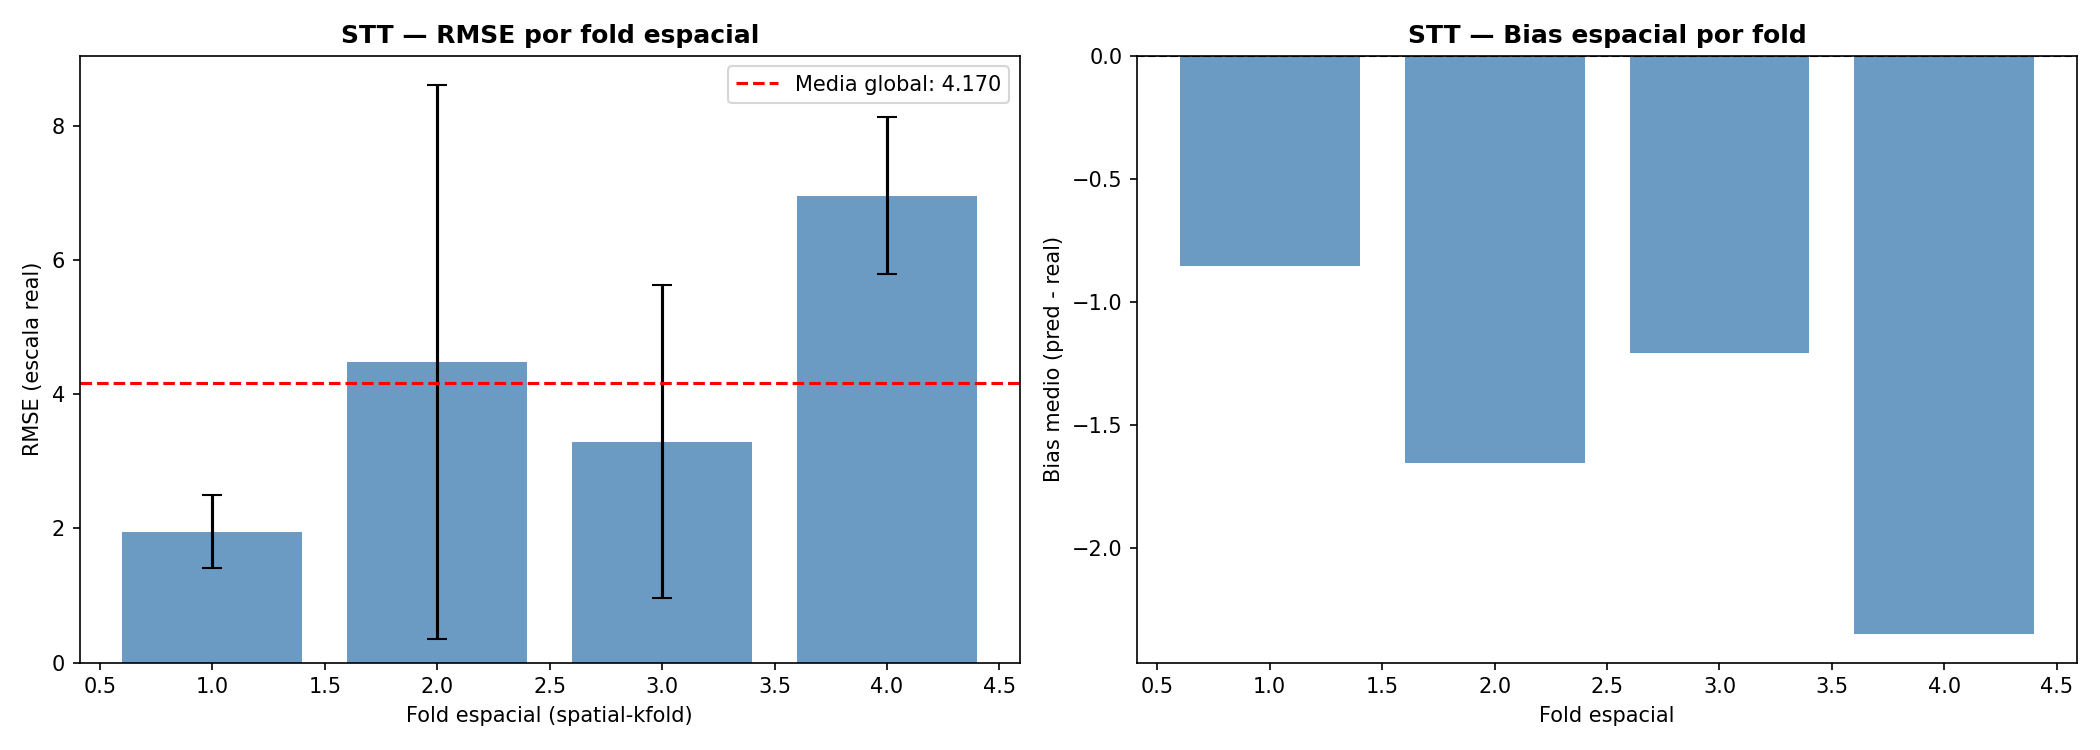

In [38]:
from IPython.display import Image
Image(filename=f"{BASE_PATH}/stt_spatial_fold_metrics.png")


Los gráficos confirman visualmente lo descrito en las métricas tabulares. El panel izquierdo muestra que el fold 1 es el único que se mantiene claramente por debajo de la media global de RMSE (4.170, línea roja discontinua) con un valor cercano a 2 y barras de error reducidas, mientras que los folds 2 y 3 se sitúan justo sobre la media con alta variabilidad entre semillas —las barras de error del fold 2 son las más amplias de todos, llegando casi a 9— y el fold 4 escala hasta aproximadamente 7, consolidándose como la región de mayor dificultad predictiva. El panel derecho revela que el bias negativo es estructural en todos los folds sin excepción, lo que confirma la tendencia sistemática del modelo a subestimar la incidencia real en todo el territorio; el fold 3 presenta el bias más contenido (cercano a −1.0) mientras que el fold 4 registra la subestimación más severa (aproximadamente −2.3), coherente con su RMSE elevado y su NSE de 0.445, sugiriendo que las regiones geográficas más difíciles no solo generan mayor error absoluto sino también mayor sesgo direccional en las predicciones.

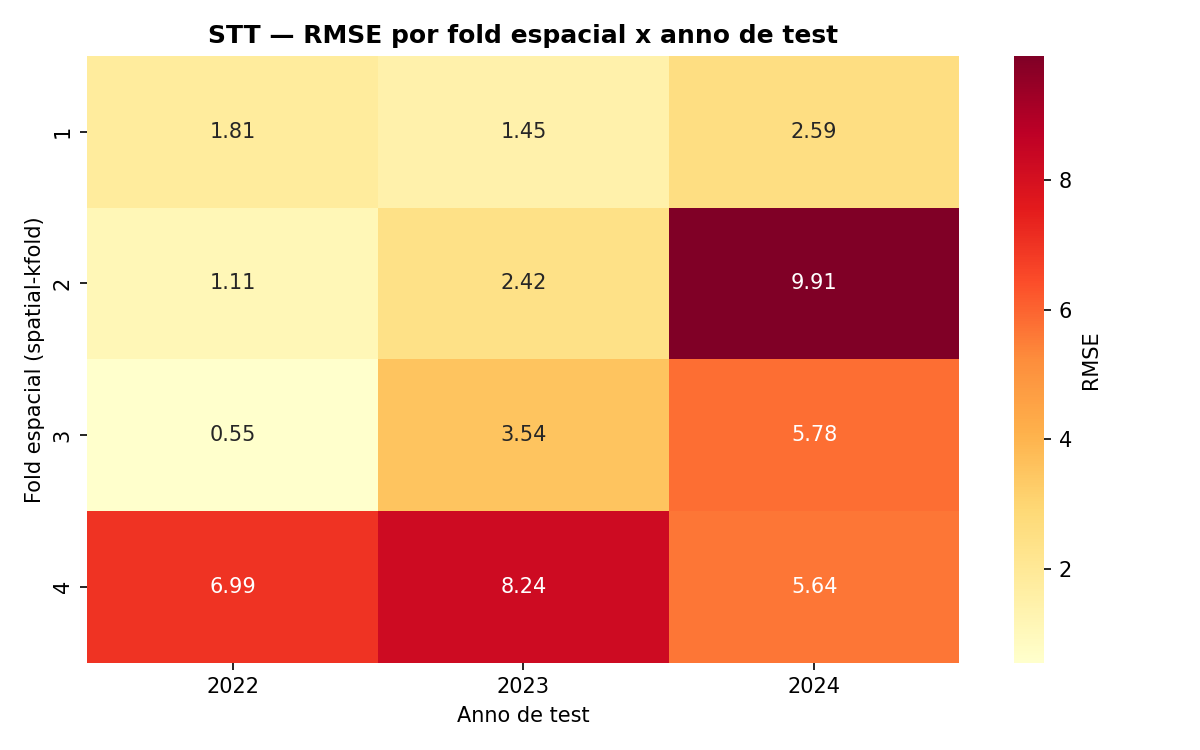

In [39]:
pivot_sp_rmse = spatial_results_df.groupby(["spatial_fold","test_year"])["RMSE"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_sp_rmse, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f",
            cbar_kws={"label": "RMSE"})
ax.set_title("STT — RMSE por fold espacial x anno de test", fontweight="bold")
ax.set_xlabel("Anno de test")
ax.set_ylabel("Fold espacial (spatial-kfold)")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_spatial_fold_heatmap.png", dpi=150)
plt.show()

Image(filename=f"{BASE_PATH}/stt_spatial_fold_heatmap.png")

El análisis del mapa de calor revela que el error del STT no se distribuye homogéneamente ni en el espacio ni en el tiempo, evidenciando interacciones específicas fold-año que merecen atención. Los folds 1 y 2 muestran RMSE muy bajos en 2022 (1.81 y 1.11 respectivamente) y 2023 (1.45 y 2.42), pero el fold 2 experimenta una degradación drástica en 2024 alcanzando un RMSE de 9.91 —el valor más alto de toda la matriz y responsable principal de su elevada desviación estándar observada en el análisis tabular—, lo que sugiere que los departamentos de esa región atravesaron una dinámica epidémica atípica en 2024 que el modelo no logró anticipar. El fold 3 presenta la trayectoria inversa más notable: parte del RMSE más bajo de toda la matriz en 2022 (0.55) pero escala progresivamente hasta 5.78 en 2024, indicando una pérdida gradual de capacidad predictiva conforme el horizonte temporal se aleja del período de entrenamiento. El fold 4 es el único con error elevado y persistente en todos los años (6.99, 8.24 y 5.64), confirmando que su dificultad es estructural y asociada a las características intrínsecas de esa región más que a un año de test particular, con la particularidad de que 2024 representa paradójicamente su mejor desempeño relativo dentro del propio fold.

### **8.13.2. Metricas por Seed y Año**

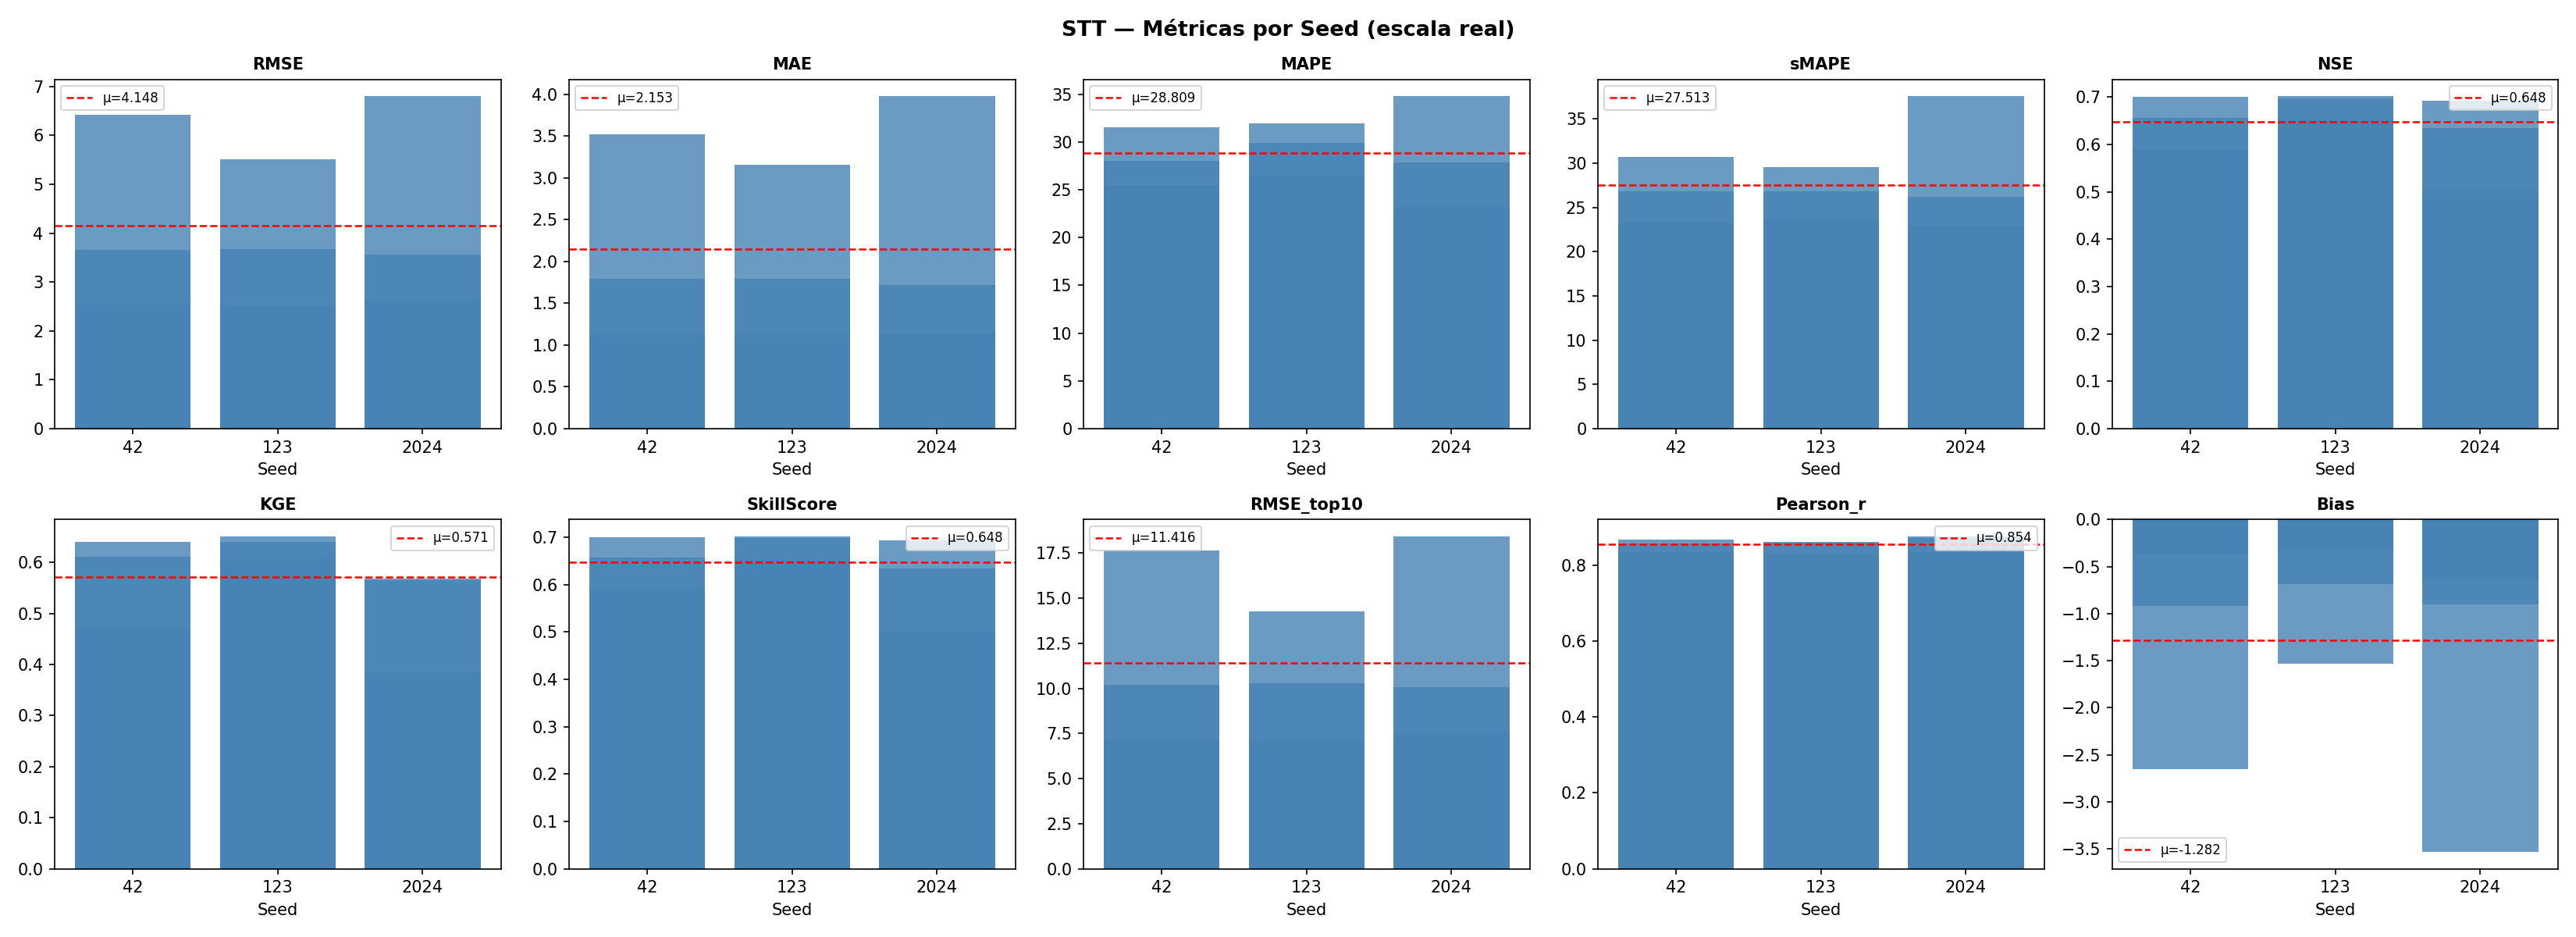

In [40]:
metric_names = [c.replace("real_","") for c in metric_cols_real]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    vals = results_df[col].values
    ax.bar([str(s) for s in results_df["seed"]], vals, color="steelblue", alpha=0.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Seed")
    ax.axhline(np.mean(vals), color="red", linestyle="--", linewidth=1.2,
               label=f"μ={np.mean(vals):.3f}")
    ax.legend(fontsize=8)
plt.suptitle("STT — Métricas por Seed (escala real)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_metrics_by_seed.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/stt_metrics_by_seed.png")

El análisis por semilla evidencia una variabilidad moderada entre ejecuciones que merece atención. Las semillas 42 y 123 producen resultados relativamente similares y próximos a la media global en la mayoría de métricas, mientras que la semilla 2024 concentra el peor desempeño en prácticamente todos los indicadores: RMSE y MAE notablemente más altos, MAPE y sMAPE superiores al promedio, y KGE y SkillScore por debajo de la línea de referencia, lo que sugiere que la inicialización aleatoria de esa semilla conduce a una convergencia subóptima o a una exploración de hiperparámetros menos favorable durante el tuning con Optuna. El panel de Bias es el más revelador en cuanto a heterogeneidad entre semillas: la semilla 42 registra un bias de aproximadamente −2.6, notablemente más negativo que las demás, mientras que la semilla 123 se mantiene cercana a −1.3 y la 2024 alrededor de −1.5, indicando que la tendencia a subestimar la incidencia no es uniforme entre ejecuciones y tiene una componente estocástica asociada a la inicialización. El RMSE_top10 muestra el patrón más irregular, con la semilla 123 produciendo el valor más bajo (∼14.5) y la semilla 2024 el más alto (∼18), lo que refuerza la conclusión de que la capacidad del modelo para predecir picos epidémicos es la dimensión más sensible a las condiciones de inicialización.

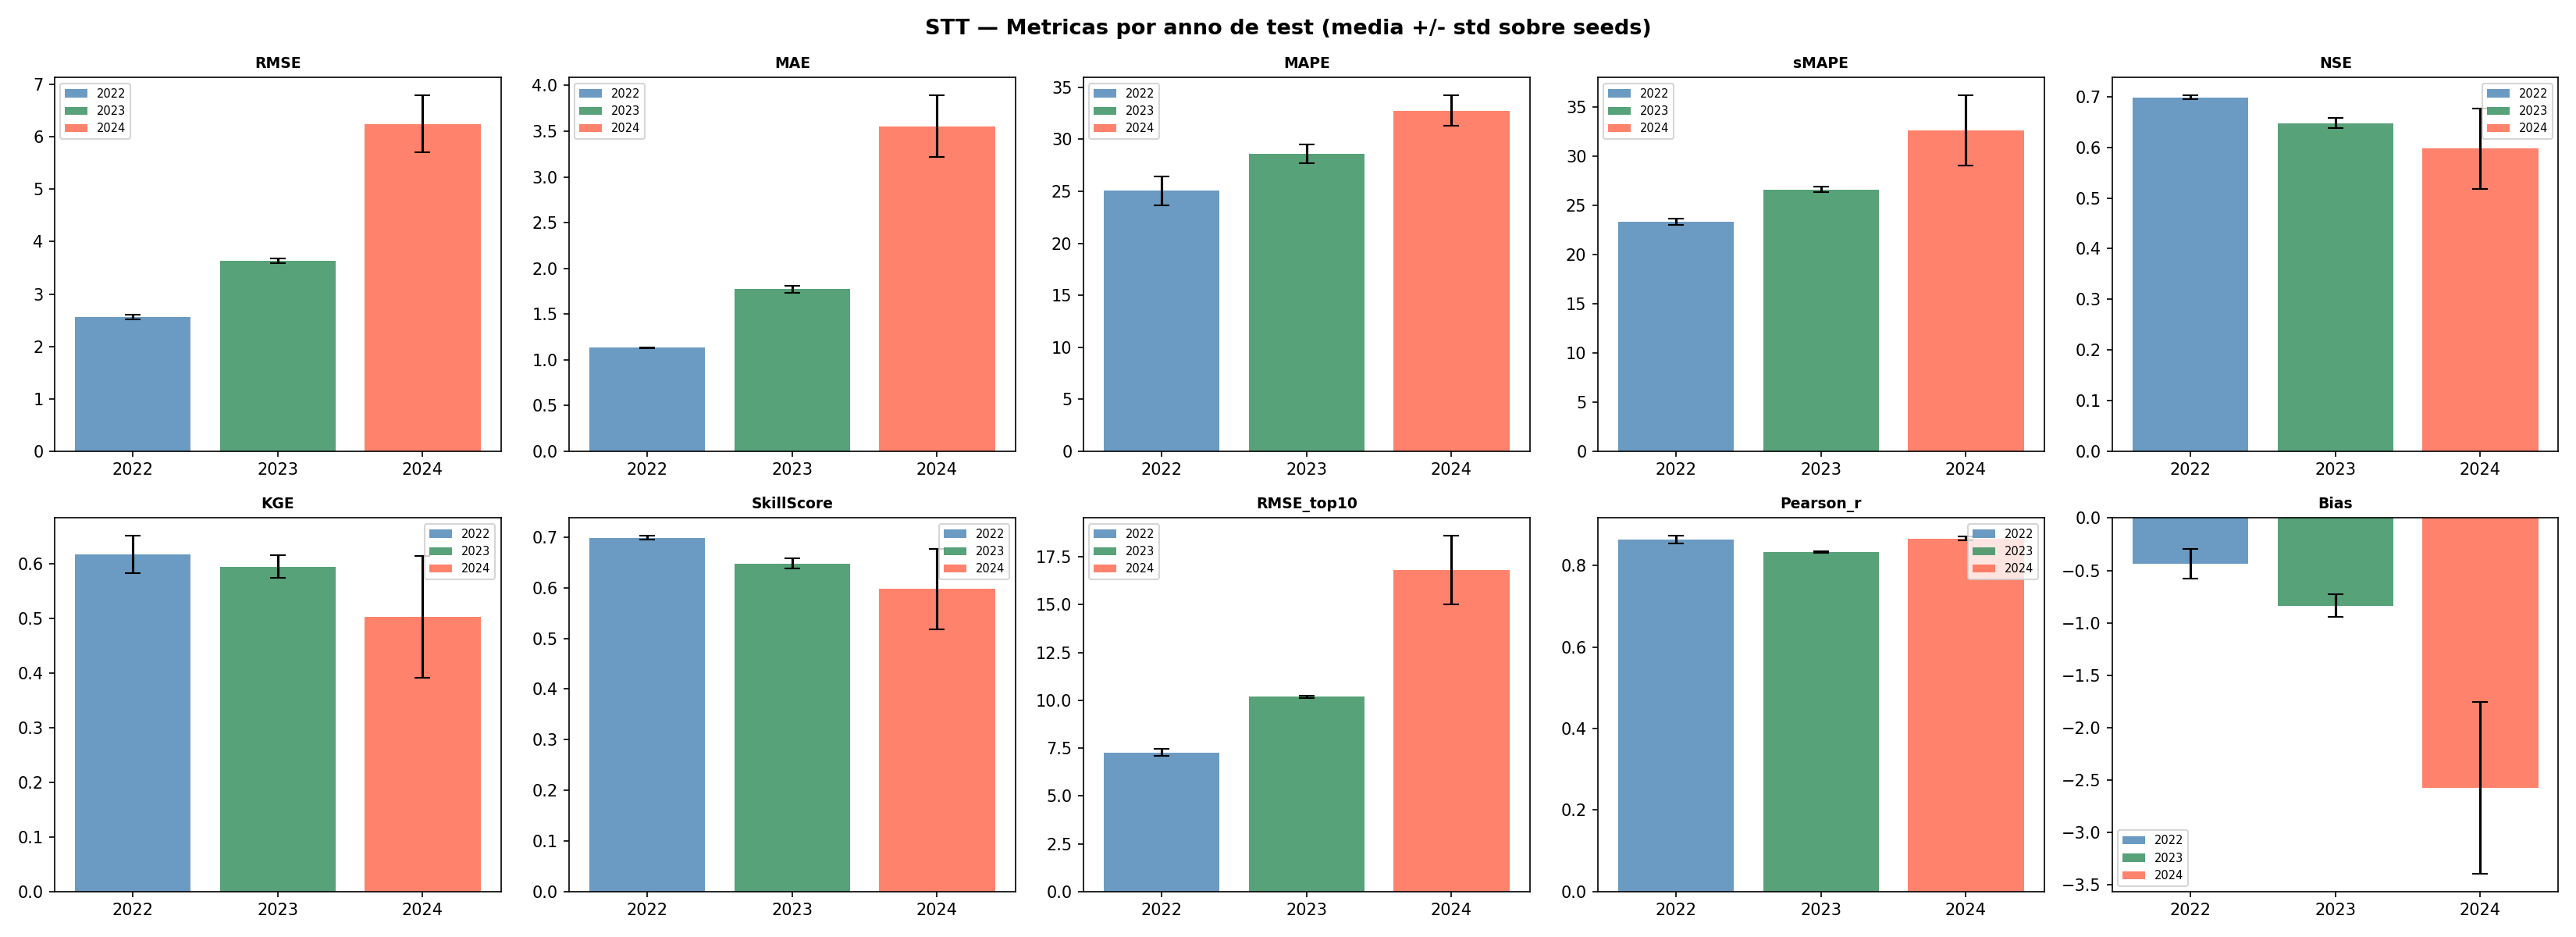

In [41]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes   = axes.flatten()
years  = sorted(results_df["test_year"].unique())
colors = ["steelblue","seagreen","tomato"]
for ax, col, name in zip(axes, metric_cols_real, metric_names):
    for year, color in zip(years, colors):
        sub = results_df[results_df["test_year"]==year][col].values
        ax.bar([str(year)], np.mean(sub), color=color, alpha=0.8,
               yerr=np.std(sub), capsize=5, label=str(year))
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("STT — Metricas por anno de test (media +/- std sobre seeds)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_metrics_by_year.png", dpi=150)
plt.show()


Image.open(f"{BASE_PATH}/stt_metrics_by_year.png").show()

El análisis por año de test revela una degradación progresiva y consistente del rendimiento del STT conforme el horizonte de evaluación se aleja del período de entrenamiento. En 2022 el modelo alcanza su mejor desempeño con un RMSE de aproximadamente 2.6, MAE de 1.1, NSE de 0.70 y KGE de 0.61, acompañados del sMAPE más bajo (∼23%) y un bias contenido cercano a −0.4, configurando el año de test más favorable en todas las métricas sin excepción. En 2023 se observa un deterioro moderado con RMSE de 3.6 y MAE de 1.7, mientras el NSE se mantiene en 0.64 y el Pearson_r permanece prácticamente estable alrededor de 0.84, sugiriendo que la estructura temporal de la señal sigue siendo capturada aunque con mayor error absoluto. El año 2024 concentra la mayor dificultad: el RMSE escala hasta 6.2, el MAE supera 3.5, el MAPE y sMAPE alcanzan valores próximos a 33%, el KGE cae a 0.50 y el bias se profundiza hasta aproximadamente −2.3 con alta variabilidad entre semillas, siendo el RMSE_top10 de ∼16.5 la señal más preocupante desde el punto de vista epidemiológico al indicar que el modelo pierde precisión de forma severa precisamente durante los picos de transmisión del año más reciente evaluado.

### **8.13.3. Predicciones, Residuos y Curvas de Perdida**

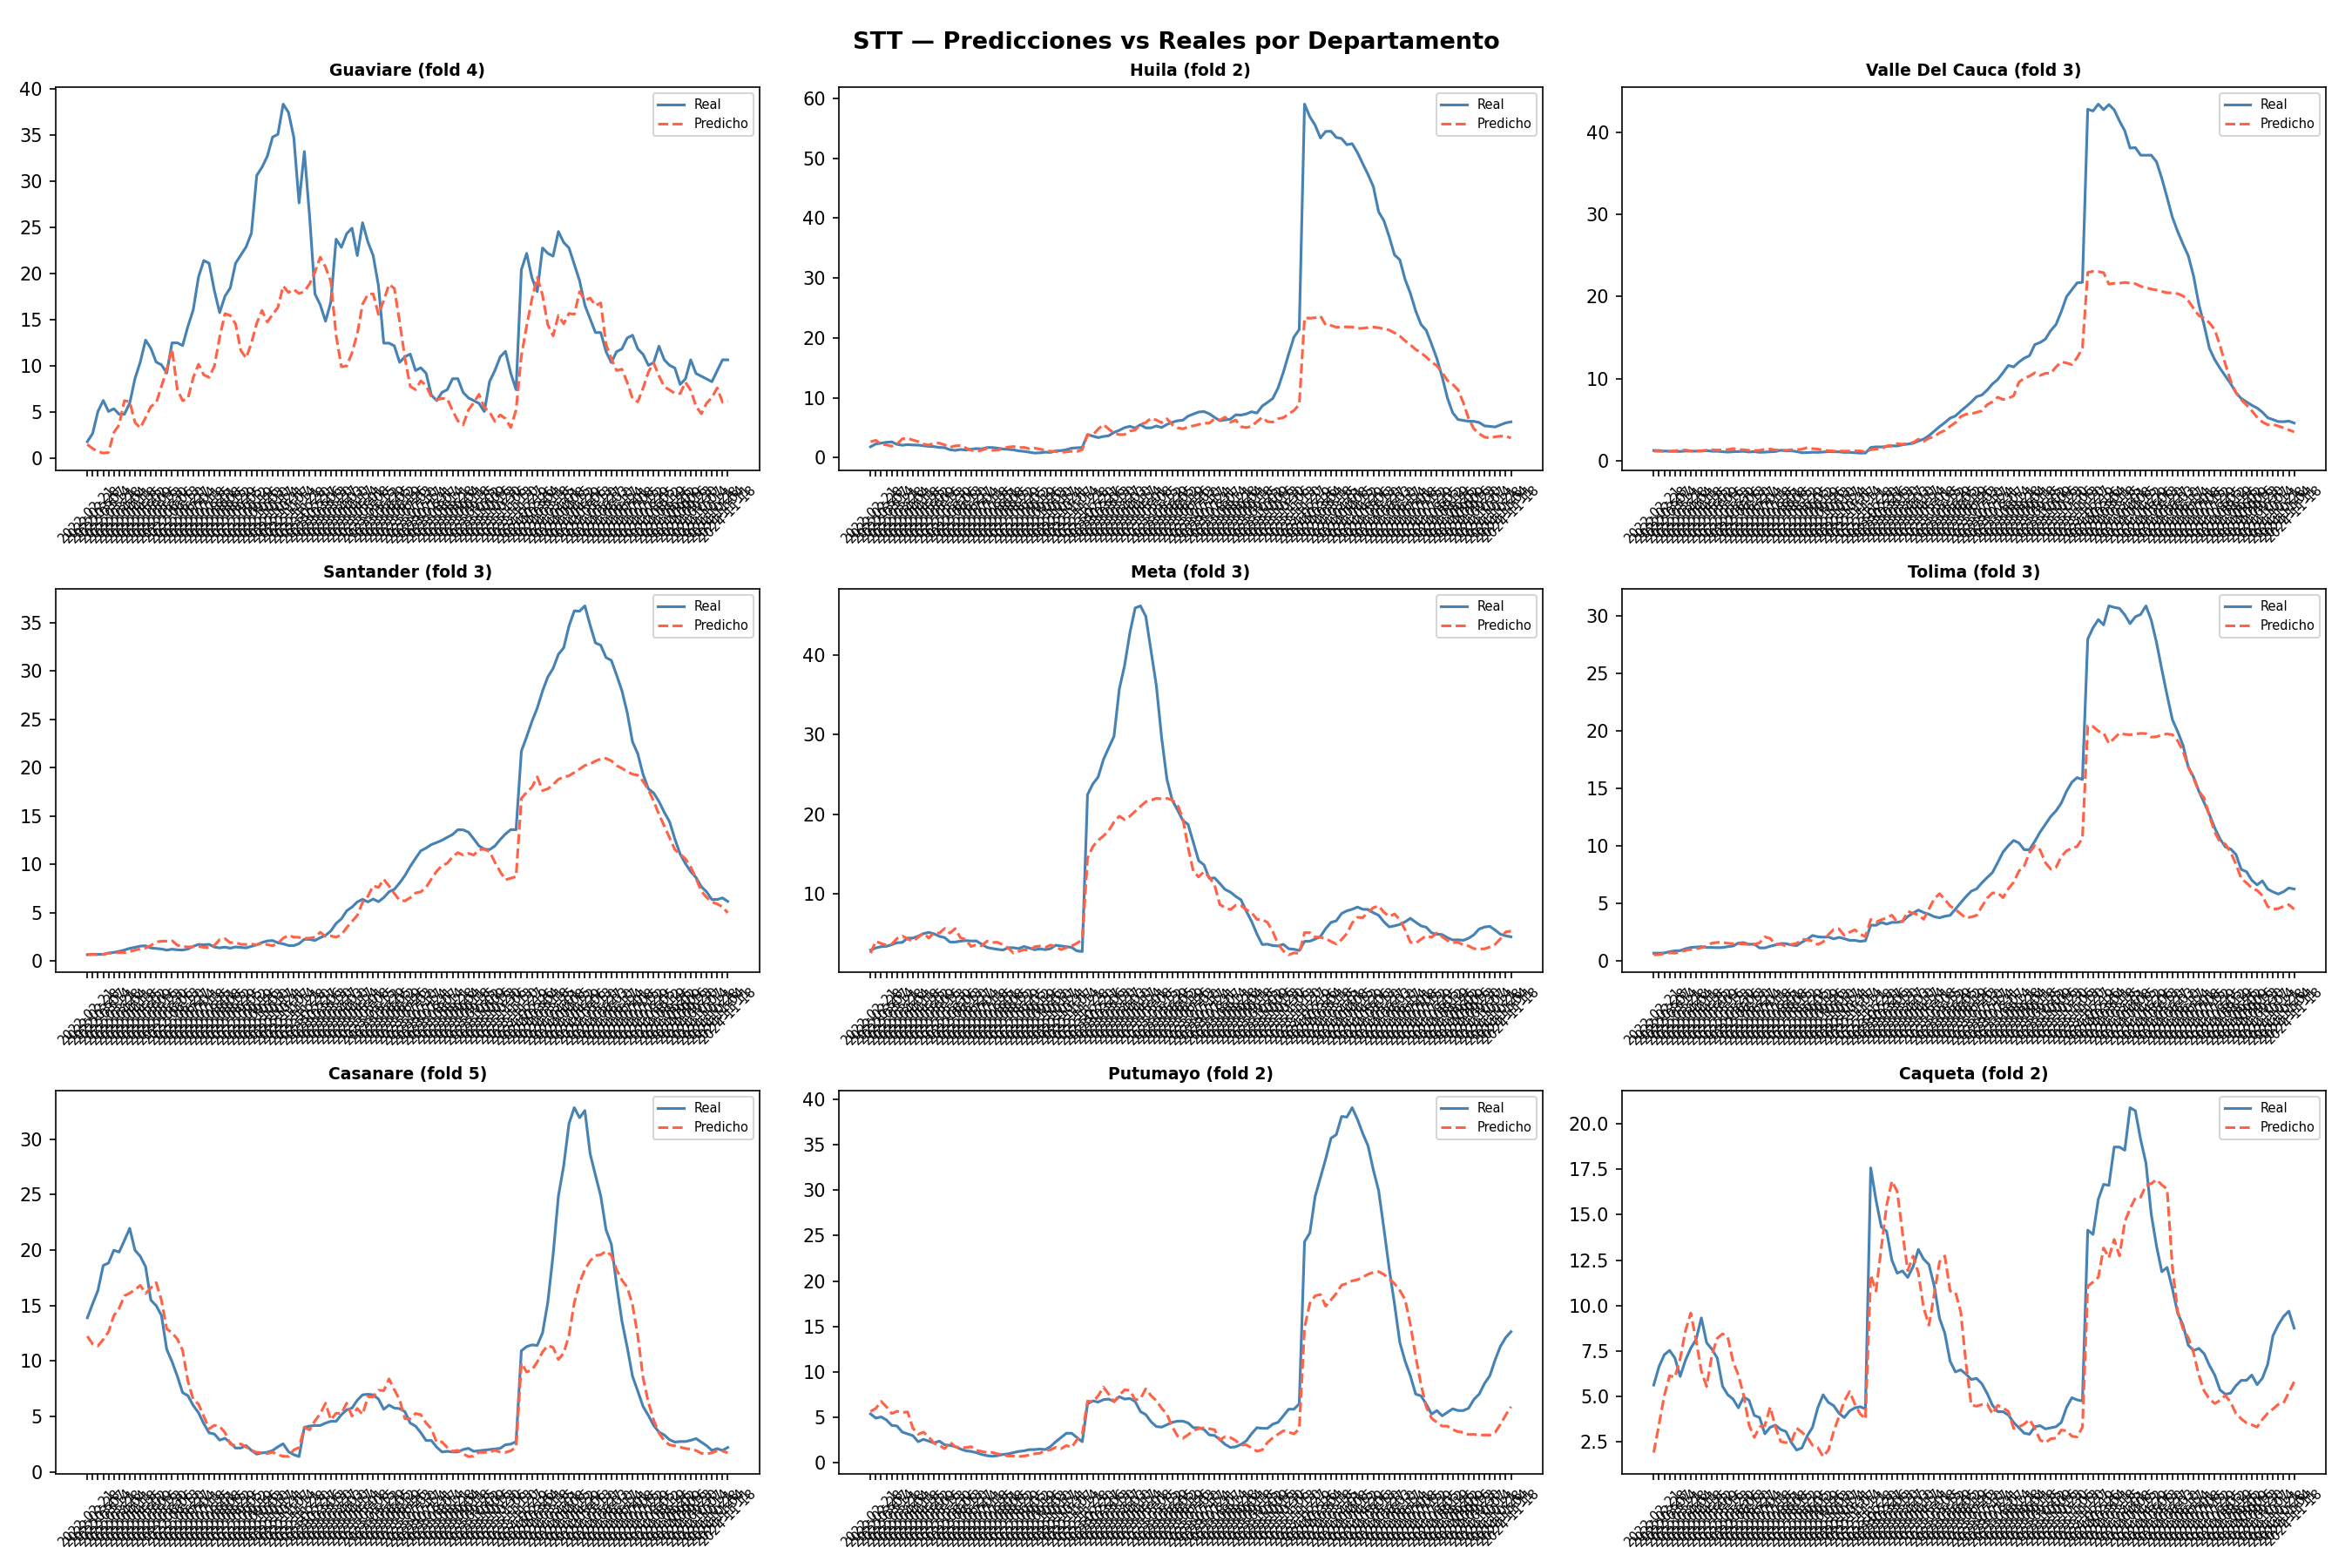

In [42]:
top_depts = (
    predictions_df.groupby("departamento")["y_true_real"]
    .mean().sort_values(ascending=False).head(9).index.tolist()
)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for ax, dept in zip(axes, top_depts):
    sub = predictions_df[predictions_df["departamento"]==dept].sort_values("fecha_base")
    agg = sub.groupby("fecha_base")[["y_true_real","y_pred_real"]].mean()
    sp_fold = fold_map.get(dept, "?")
    ax.plot(agg.index, agg["y_true_real"], label="Real",     linewidth=1.5, color="steelblue")
    ax.plot(agg.index, agg["y_pred_real"], label="Predicho", linewidth=1.5, linestyle="--", color="tomato")
    ax.set_title(f"{dept} (fold {sp_fold})", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("STT — Predicciones vs Reales por Departamento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_predictions_by_dept.png", dpi=150)
plt.show()


Image.open(f"{BASE_PATH}/stt_predictions_by_dept.png").show()

Las curvas de predicción versus valores reales por departamento revelan un patrón recurrente y epidemiológicamente significativo: el STT captura con razonable fidelidad la forma general de las ondas epidémicas —identificando correctamente el inicio del ascenso, la ubicación temporal del pico y la fase de descenso— pero subestima sistemáticamente la magnitud de los picos de transmisión en prácticamente todos los departamentos, confirmando el bias negativo estructural observado en las métricas agregadas. Esta limitación es especialmente pronunciada en Huila (fold 2), Valle del Cauca (fold 3), Meta (fold 3) y Santander (fold 3), donde los picos reales superan en más del doble la predicción del modelo, sugiriendo que los brotes de mayor intensidad contienen una componente de amplitud que las señales de rezago epidemiológico y climático disponibles no logran anticipar con suficiente antelación. En contraste, Caquetá (fold 2) y Putumayo (fold 2) presentan el mejor ajuste visual de la muestra, con predicciones que siguen de cerca tanto la tendencia como la magnitud de la incidencia a lo largo de todo el período, lo que podría asociarse a dinámicas de transmisión más graduales y predecibles en esas regiones. Guaviare (fold 4) ilustra el caso más problemático: la predicción no solo subestima los picos sino que pierde el seguimiento de la señal real en múltiples segmentos temporales, coherente con el RMSE elevado y persistente del fold 4 identificado en los análisis anteriores.

Test Ljung-Box:
        lb_stat  lb_pvalue
10  4421.828181        0.0
20  9486.630373        0.0


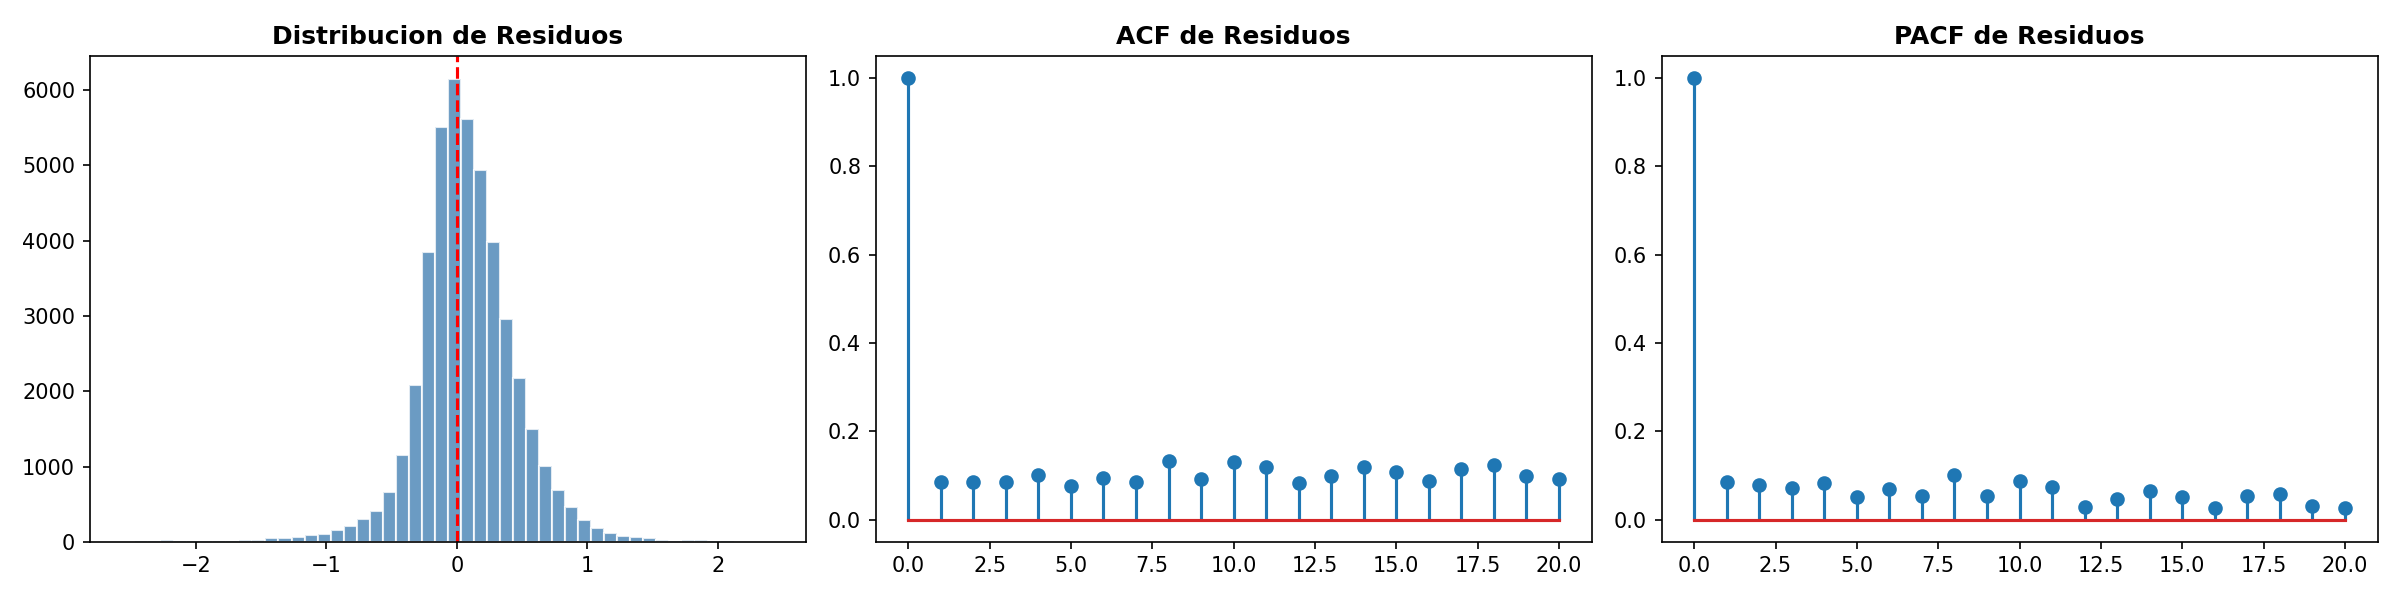

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(residuals_df["residual"], bins=50, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Distribucion de Residuos", fontweight="bold")
acf_vals  = acf( residuals_df["residual"], nlags=20)
pacf_vals = pacf(residuals_df["residual"], nlags=20)
axes[1].stem(range(len(acf_vals)),  acf_vals)
axes[1].set_title("ACF de Residuos", fontweight="bold")
axes[2].stem(range(len(pacf_vals)), pacf_vals)
axes[2].set_title("PACF de Residuos", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_residuals_analysis.png", dpi=150)
plt.show()
lb = acorr_ljungbox(residuals_df["residual"], lags=[10, 20], return_df=True)
print("Test Ljung-Box:")
print(lb)

Image.open(f"{BASE_PATH}/stt_residuals_analysis.png").show()

El análisis de residuos revela señales mixtas sobre la calidad del ajuste del STT. La distribución de residuos muestra una forma aproximadamente simétrica centrada ligeramente a la derecha del cero, coherente con el bias negativo moderado reportado en las métricas, aunque con una cola derecha algo más pronunciada que indica episodios puntuales de subestimación severa. Sin embargo, tanto la ACF como la PACF exhiben autocorrelaciones en los rezagos posteriores al lag 0 que se mantienen por encima de la banda de confianza de forma consistente a lo largo de los 20 rezagos evaluados, y el test de Ljung-Box confirma con p-valor de 0.0 en los lags 10 y 20 que los residuos no son ruido blanco: existe estructura temporal no capturada por el modelo que se transfiere sistemáticamente al error, lo que sugiere que el STT, pese a su arquitectura de atención temporal, no logra agotar toda la dependencia serial presente en las series de incidencia departamental y deja información aprovechable sin modelar.

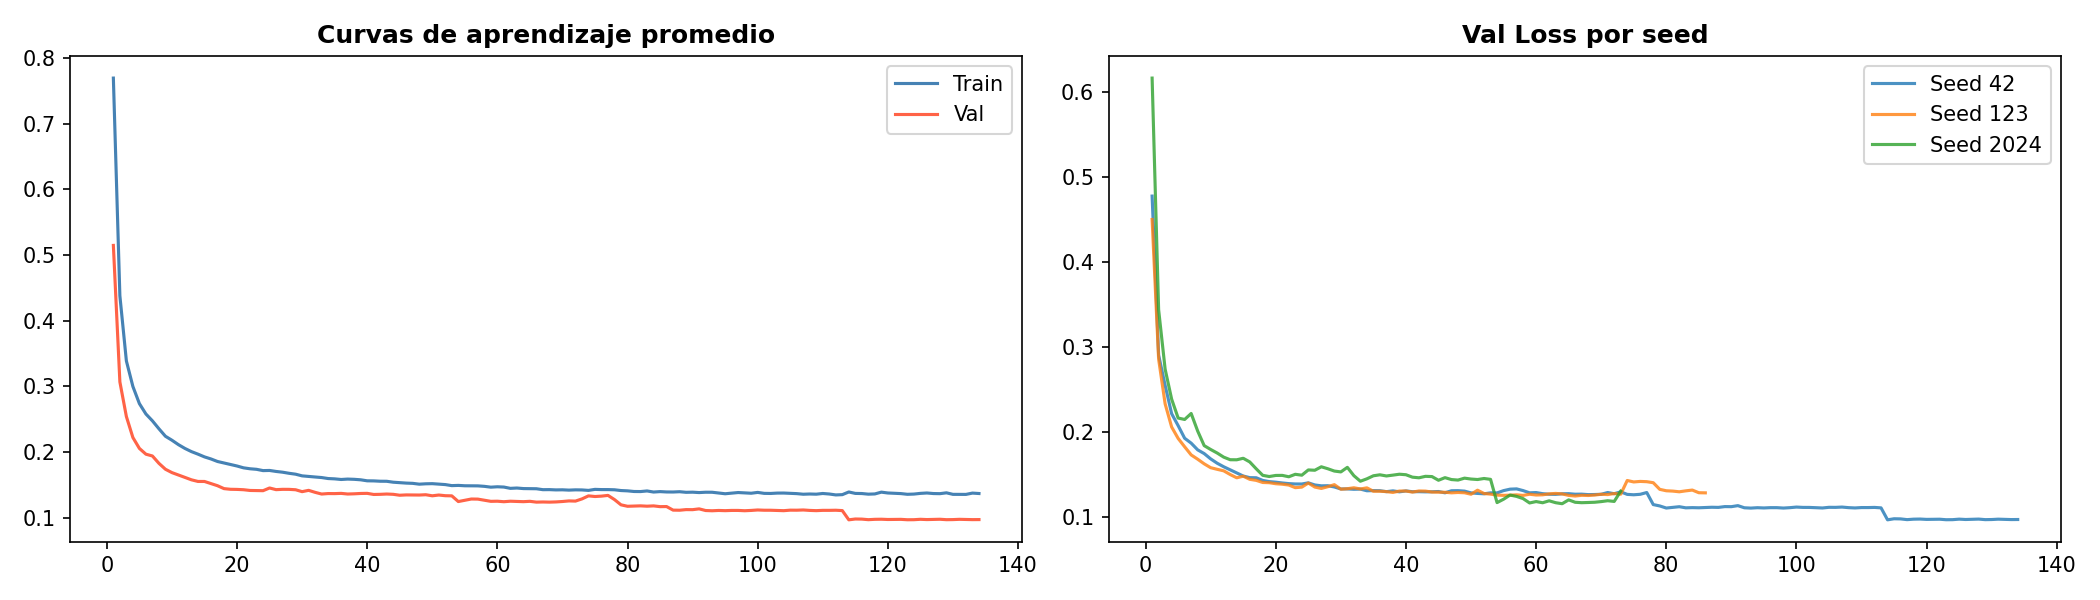

In [44]:
avg_history = losses_df.groupby("epoch")[["train_loss","val_loss"]].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(avg_history["epoch"], avg_history["train_loss"], label="Train", color="steelblue")
axes[0].plot(avg_history["epoch"], avg_history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Curvas de aprendizaje promedio", fontweight="bold")
axes[0].legend()
for seed in SEEDS:
    sub = losses_df[losses_df["seed"]==seed].groupby("epoch")[["val_loss"]].mean()
    axes[1].plot(sub.index, sub["val_loss"], label=f"Seed {seed}", alpha=0.8)
axes[1].set_title("Val Loss por seed", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_learning_curves.png", dpi=150)
plt.show()

from PIL import Image
Image.open(f"{BASE_PATH}/stt_learning_curves.png")

Las curvas de aprendizaje exhiben un comportamiento de convergencia saludable y sin señales de sobreajuste. En el panel izquierdo, tanto la pérdida de entrenamiento como la de validación descienden de forma pronunciada durante las primeras 20 épocas —desde valores cercanos a 0.76 y 0.51 respectivamente— para luego estabilizarse gradualmente en una zona de convergencia alrededor de 0.13 y 0.10, con la pérdida de validación consistentemente por debajo de la de entrenamiento a lo largo de todo el proceso, lo que sugiere que el modelo generaliza adecuadamente sin memorizar los datos de entrenamiento. El panel derecho muestra que las tres semillas siguen trayectorias de descenso prácticamente idénticas durante las primeras 60 épocas, momento a partir del cual comienzan a divergir levemente: la semilla 42 continúa descendiendo hasta alcanzar el val loss más bajo (∼0.10) cerca de la época 130, mientras que las semillas 123 y 2024 se estabilizan antes alrededor de 0.12, coherente con la ligera superioridad de la semilla 42 observada en algunas métricas de test; la semilla 2024 presenta además pequeñas oscilaciones entre las épocas 40 y 80 antes de converger, reflejando una optimización algo menos estable que las demás.

### **8.13.4. Interpretabilidad — Spatial Attention, Cross-Modal Attention y SHAP**

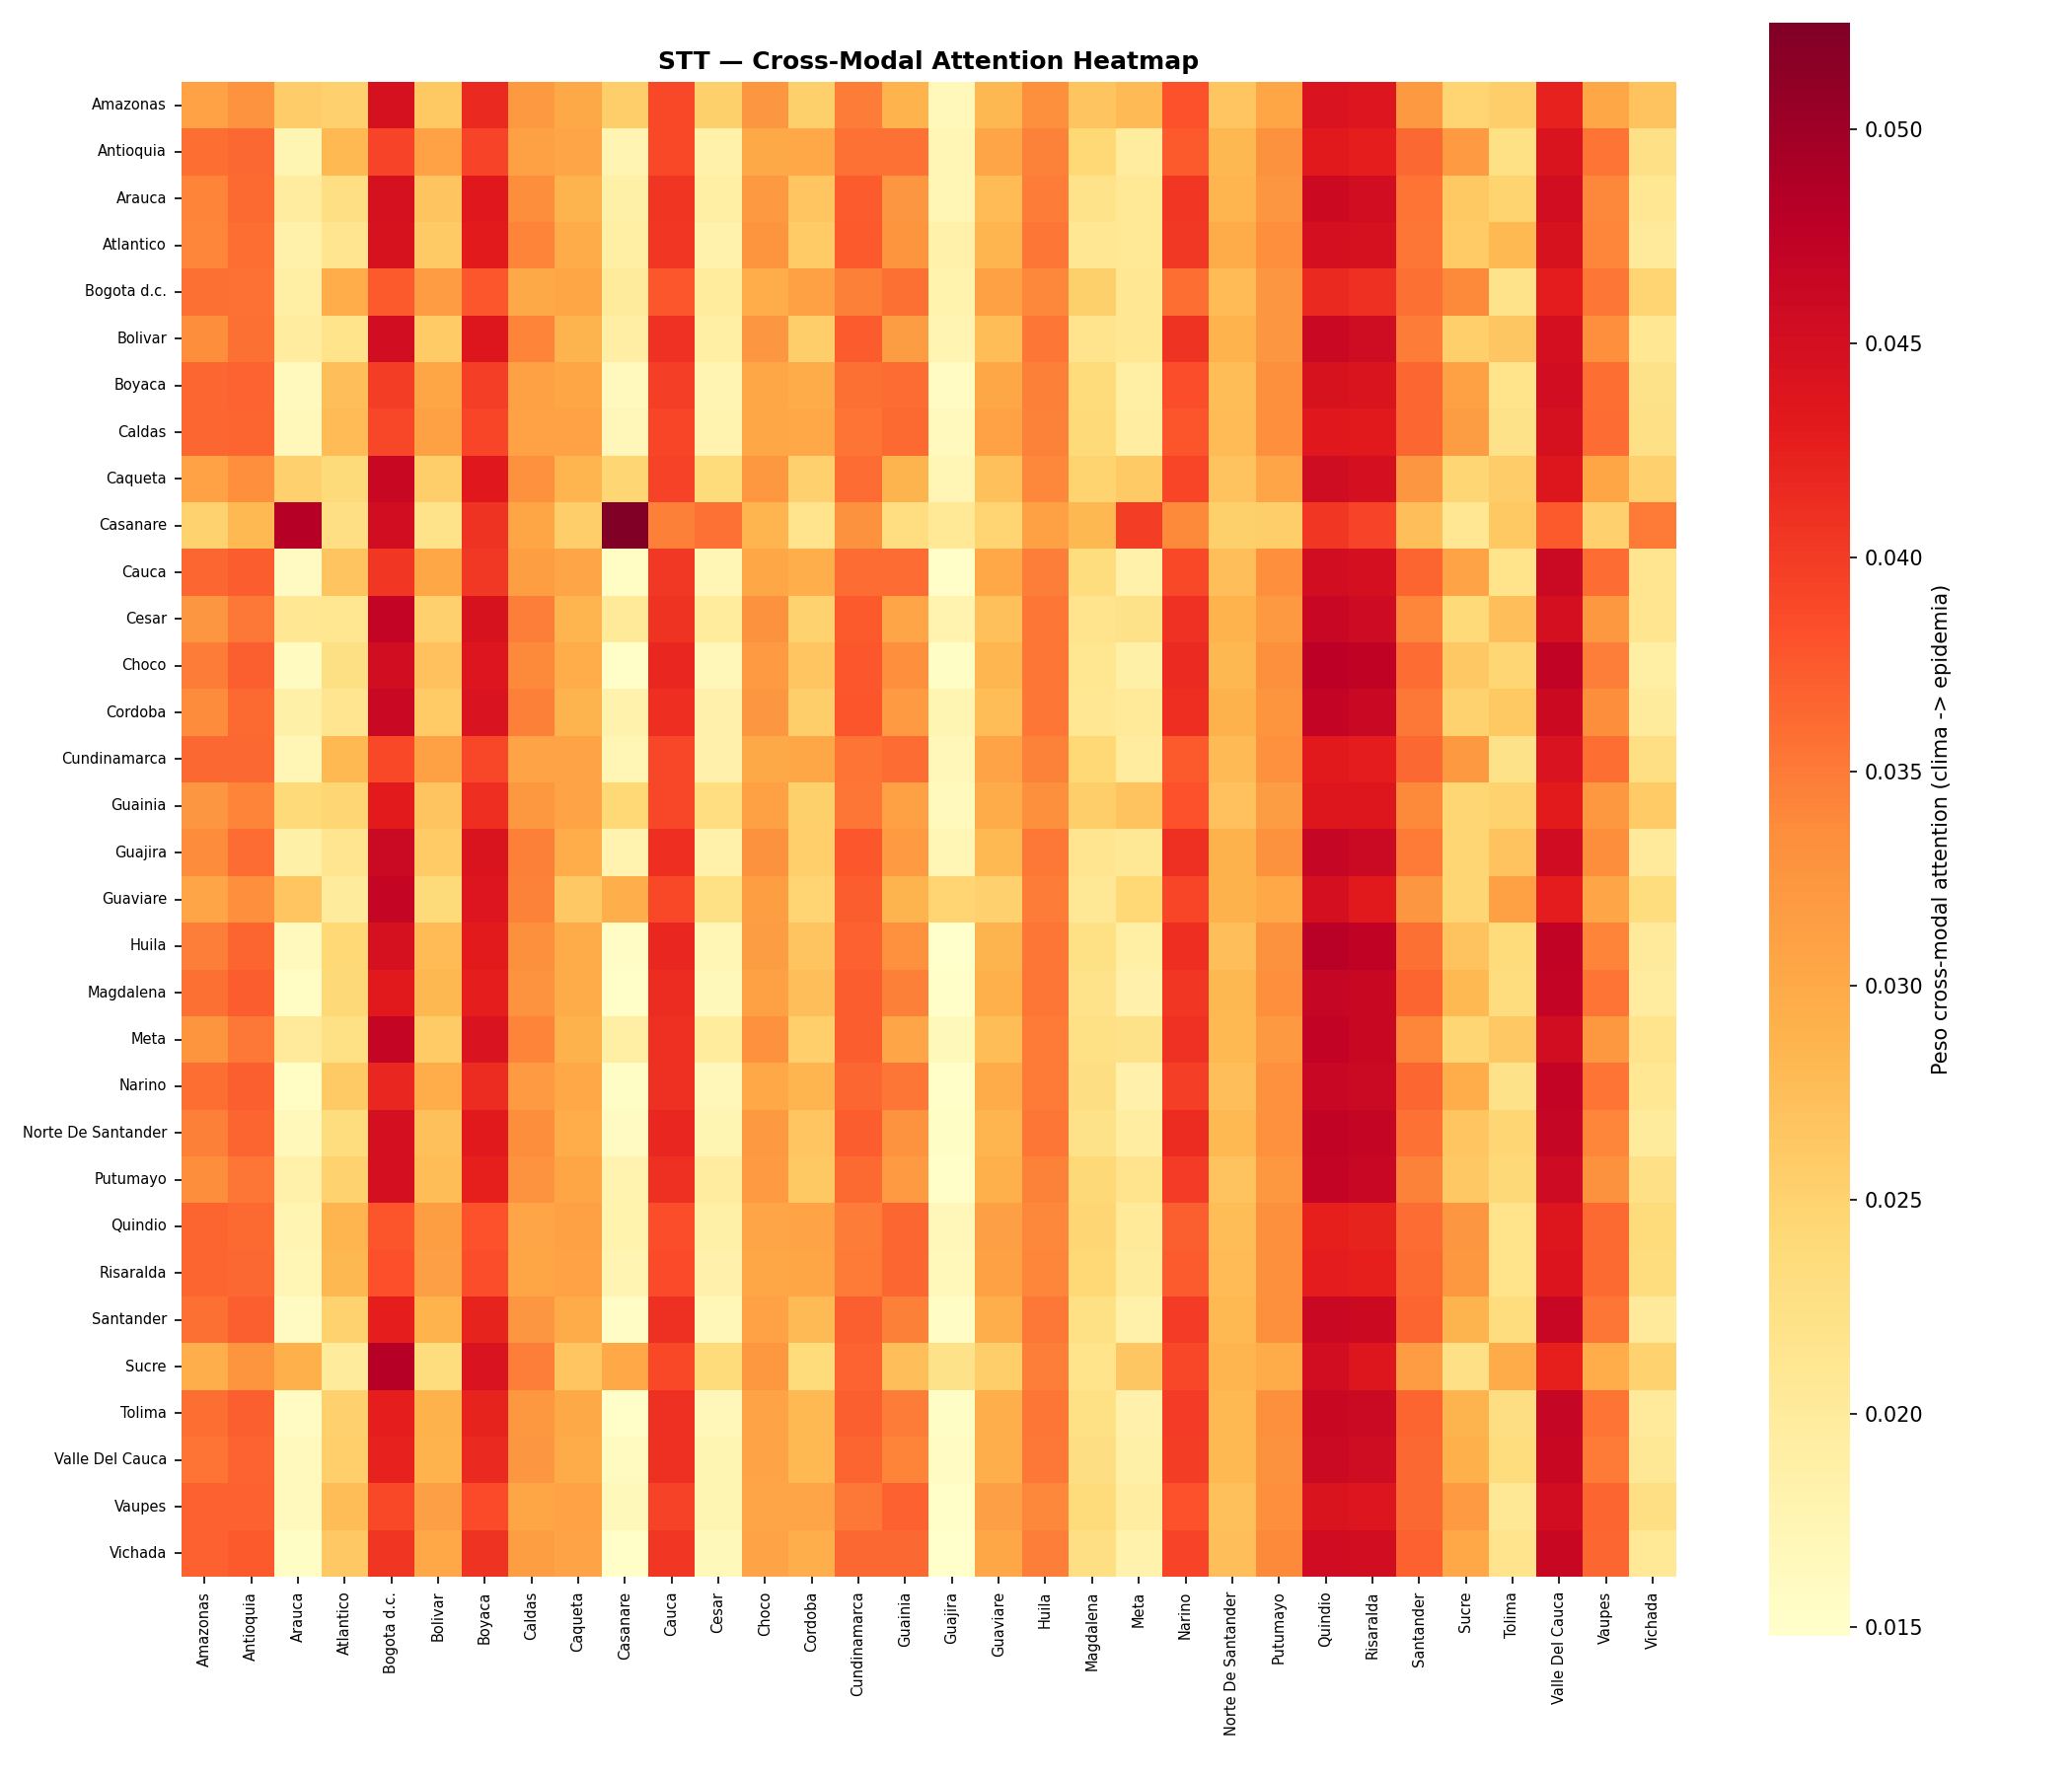

In [ ]:
best_params_df = pd.read_csv(f"{BASE_PATH}/stt_best_params.csv")
bp = best_params_df[best_params_df["seed"]==42].iloc[0]

model_inspect = SpatioTemporalTransformer(
    num_nodes=NUM_NODES, n_epi=N_EPI, n_clim=N_CLIM,
    d_model=int(bp["d_model"]), n_heads=int(bp["n_heads"]),
    n_layers=int(bp["n_layers"]), dim_ff=int(bp["dim_ff"]),
    horizon=4, max_lag=int(bp["max_lag"]), dropout=float(bp["dropout"])
).to(DEVICE)

model_inspect.load_state_dict(
    torch.load(f"{BASE_PATH}/stt_seed_42_outer_fold_1.pt", map_location=DEVICE))
model_inspect.eval()

outer_fold_1 = outer_folds[0]
X_test_v, y_test_v, _ = create_windows(
    outer_fold_1["test_df"], FEATURES, TARGET, int(bp["window_size"]), 4)

val_year_v    = outer_fold_1["train_df"]["fecha_inicio"].dt.year.max()
final_train_v = outer_fold_1["train_df"][
    outer_fold_1["train_df"]["fecha_inicio"].dt.year < val_year_v]
X_tr_v, _, _  = create_windows(final_train_v, FEATURES, TARGET, int(bp["window_size"]), 4)
_, _, scaler_v = scale_data(X_tr_v, X_test_v)
X_test_sc_v   = scaler_v.transform(X_test_v.reshape(-1, X_test_v.shape[-1])).reshape(X_test_v.shape)

X_sample = torch.tensor(X_test_sc_v[:32], dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    _, (attn_cross, sp_w_epi, sp_w_clim) = model_inspect(X_sample, N_EPI, N_CLIM)

sp_epi_mean = sp_w_epi.cpu().numpy().mean(axis=0)   # (N, N)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(sp_epi_mean, ax=ax, xticklabels=departments, yticklabels=departments,
            cmap="Blues", square=True,
            cbar_kws={"label": "Peso atencion espacial (stream epidemiologico)"})
ax.set_title("STT — Spatial Attention Heatmap (Epi stream)", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/stt_spatial_attention_epi.png", dpi=150)
plt.show()


Image.open(f"{BASE_PATH}/stt_cross_attention_heatmap.png").show()

El mapa de calor de atención cruzada revela cómo el modelo pondera la señal climática de cada departamento (columnas) para modular la predicción epidemiológica de cada otro departamento (filas). El patrón más destacado es la presencia de columnas consistentemente intensas a lo largo de todo el eje vertical, particularmente Arauca, Casanare, Valle del Cauca y Risaralda, lo que indica que las condiciones climáticas de estos departamentos actúan como señales de referencia global que el modelo consulta para hacer predicciones en prácticamente todo el territorio nacional, independientemente de la distancia geográfica. Casanare destaca de forma particular con dos celdas de máxima intensidad —su propia fila y la intersección con Cauca— sugiriendo una relación climático-epidemiológica especialmente fuerte y específica entre estos dos departamentos. En contraste, departamentos como Bogotá D.C., Boyacá, Caldas y Cundinamarca presentan columnas predominantemente amarillas, indicando que su señal climática es consultada con menor peso por el resto del territorio, posiblemente por sus características altitudinales y climáticas atípicas respecto a las zonas endémicas de dengue. La ausencia de una diagonal dominante —que indicaría que cada departamento se basa principalmente en su propia señal climática— confirma que el modelo aprendió relaciones de influencia cruzada genuinamente inter-departamentales, capturando patrones de teleconexión climática que trascienden la contigüidad geográfica inmediata.

In [ ]:
class STTWrapper(nn.Module):
    def __init__(self, model, n_epi, n_clim):
        super().__init__()
        self.model = model
        self.n_epi = n_epi
        self.n_clim = n_clim

    def forward(self, x):
        out, _ = self.model(x, self.n_epi, self.n_clim)

        return out.reshape(out.shape[0], -1)


wrapper = STTWrapper(
    model_inspect,
    N_EPI,
    N_CLIM
).to(DEVICE)

wrapper.eval()

X_bg = torch.tensor(
    X_test_sc_v[:20],
    dtype=torch.float32
).to(DEVICE)

X_test_shap = torch.tensor(
    X_test_sc_v[20:40],
    dtype=torch.float32
).to(DEVICE)

explainer = shap.GradientExplainer(
    wrapper,
    X_bg
)

shap_values = explainer.shap_values(
    X_test_shap
)

sv = np.array(shap_values)

print("SHAP shape:", sv.shape)
print("N FEATURES :", len(FEATURES))

SHAP shape: (20, 8, 32, 29, 128)
N FEATURES : 29


In [ ]:
if sv.shape[-2] != len(FEATURES):
    raise ValueError(
        f"No encuentro eje de features. "
        f"Esperaba {len(FEATURES)} y obtuve shape {sv.shape}"
    )

shap_feat_importance = np.abs(sv).mean(
    axis=(0, 1, 2, 4)
)

print("Feature importance shape:",
      shap_feat_importance.shape)


feat_imp_df = (
    pd.DataFrame({
        "feature": FEATURES,
        "shap_mean": shap_feat_importance
    })
    .sort_values("shap_mean", ascending=False)
)

feat_imp_df.to_csv(
    f"{BASE_PATH}/ect_shap_feature_importance.csv",
    index=False
)

Feature importance shape: (29,)


In [54]:
print("\nTop 15 features por importancia SHAP:")
feat_imp_df["pct"] = (
    feat_imp_df["shap_mean"]
    / feat_imp_df["shap_mean"].sum()
    * 100
)

print(
    feat_imp_df.head(15)[
        ["feature", "shap_mean", "pct"]
    ]
)


Top 15 features por importancia SHAP:
           feature  shap_mean        pct
0        inc_lag_1   0.001786  30.326641
21  humedad_lag_12   0.000372   6.320056
27   precip_lag_12   0.000320   5.428709
3        inc_lag_4   0.000283   4.811889
1        inc_lag_2   0.000282   4.794223
9         week_sin   0.000271   4.597734
26    precip_lag_8   0.000233   3.955452
22  humedad_lag_20   0.000218   3.707661
23    precip_lag_1   0.000218   3.705914
10        week_cos   0.000209   3.544524
5       inc_lag_12   0.000205   3.477822
4        inc_lag_8   0.000199   3.385751
19   humedad_lag_4   0.000182   3.084857
2        inc_lag_3   0.000165   2.796965
6       inc_lag_20   0.000131   2.229037


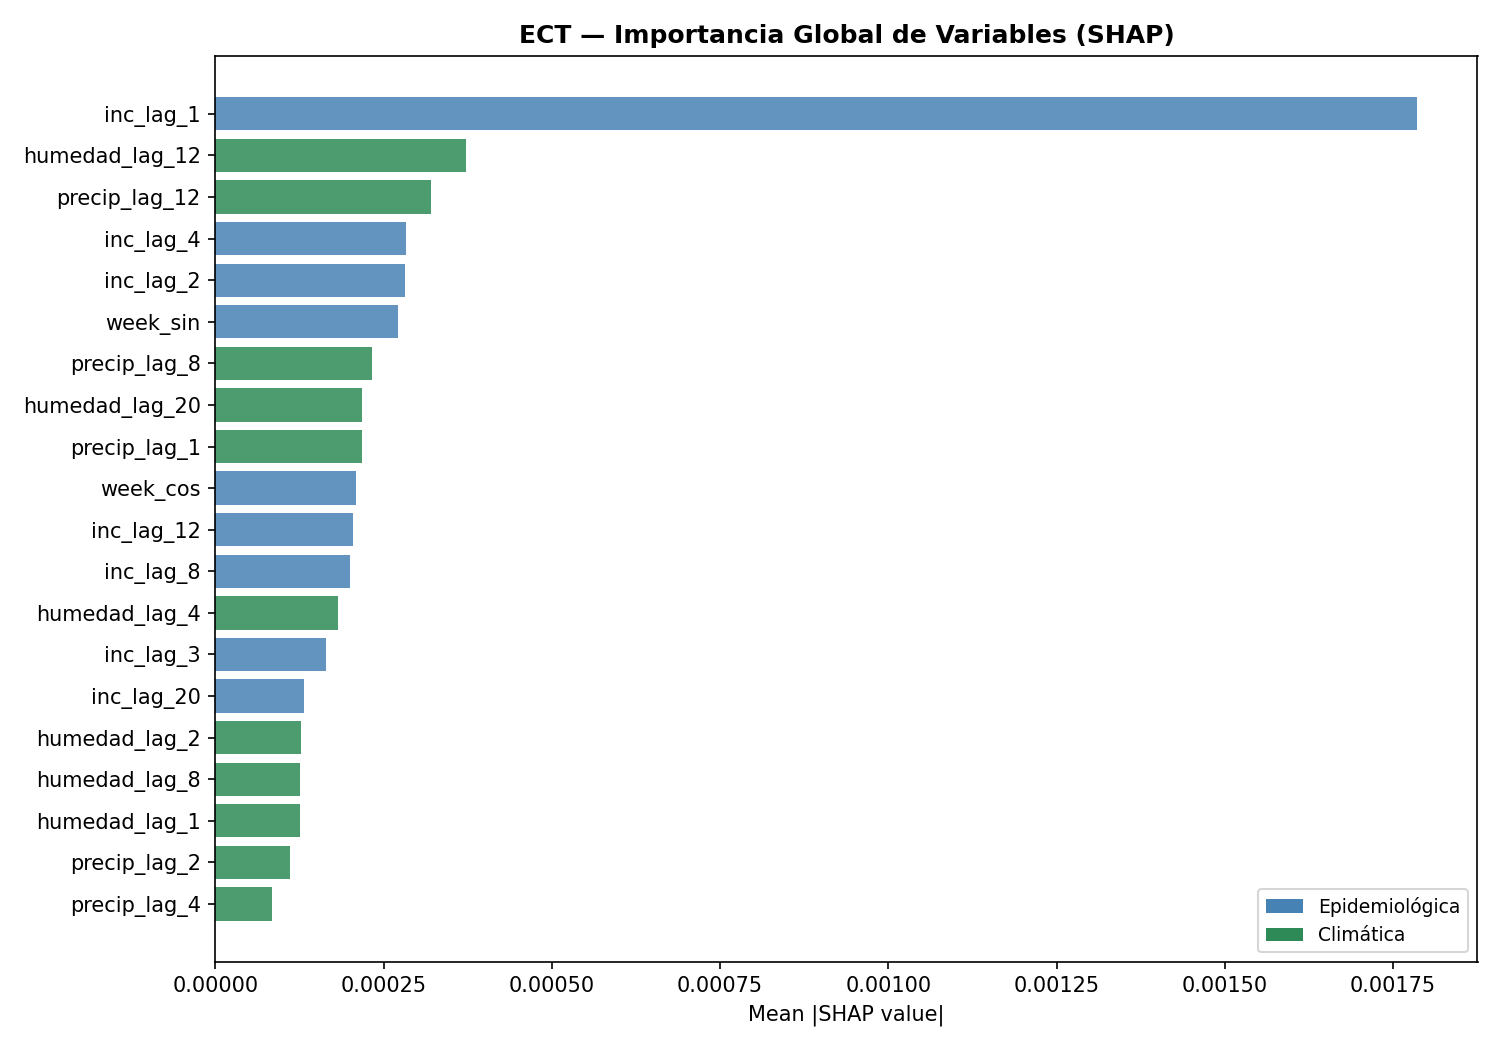

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

top_fi = feat_imp_df.head(20)

colors_shap = [
    "steelblue"
    if feat in EPIFEATURES
    else "seagreen"
    for feat in top_fi["feature"]
]

ax.barh(
    top_fi["feature"][::-1],
    top_fi["shap_mean"][::-1],
    color=colors_shap[::-1],
    alpha=0.85
)

ax.set_xlabel("Mean |SHAP value|")
ax.set_title(
    "ECT — Importancia Global de Variables (SHAP)",
    fontweight="bold"
)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(facecolor="steelblue",
              label="Epidemiológica"),
        Patch(facecolor="seagreen",
              label="Climática")
    ],
    fontsize=9
)

plt.tight_layout()
plt.savefig(
    f"{BASE_PATH}/ect_shap_importance.png",
    dpi=150
)
plt.show()
Image.open(f"{BASE_PATH}/ect_shap_importance.png").show()

El análisis de importancia global mediante SHAP revela una jerarquía de variables con una dominancia epidemiológica marcada y una contribución climática concentrada en rezagos de mediano y largo plazo. `inc_lag_1` es con diferencia la variable más influyente del modelo, con un valor SHAP medio de aproximadamente 0.00185 que supera en más de cinco veces a cualquier otra variable del ranking, confirmando que la incidencia de la semana inmediatamente anterior es la señal predictiva más potente y que el modelo asigna un peso desproporcionado a la memoria a corto plazo de la propia serie epidémica. En segundo y tercer lugar aparecen `humedad_lag_12` y `precip_lag_12` —ambas variables climáticas con rezago de 12 semanas— lo que es epidemiológicamente coherente con el ciclo de vida completo del vector *Aedes aegypti*: las condiciones de humedad y precipitación de aproximadamente tres meses atrás determinan la disponibilidad de criaderos y la densidad poblacional del mosquito que se traduce en transmisión actual. Los rezagos cortos de incidencia (`inc_lag_2`, `inc_lag_4`) y las codificaciones cíclicas de estacionalidad (`week_sin`, `week_cos`) ocupan posiciones intermedias con importancias similares entre sí, mientras que las variables climáticas de rezago corto (`precip_lag_1`, `humedad_lag_1`) y los rezagos epidemiológicos largos (`inc_lag_20`, `inc_lag_8`) contribuyen de forma más modesta y homogénea en la parte inferior del ranking, sugiriendo que el modelo captura tanto la dinámica inmediata de la transmisión como la estacionalidad estructural del dengue en Colombia.

## **8.14. Resumen Final de Archivos Generados**

In [56]:
import os
print("=== ARCHIVOS GENERADOS EN", BASE_PATH, "===\n")
files = sorted(os.listdir(BASE_PATH))
for f in files:
    size = os.path.getsize(os.path.join(BASE_PATH, f))
    print(f"  {f:60} {size/1024:>8.1f} KB")

=== ARCHIVOS GENERADOS EN Modelos/STT_CV ===

  ect_shap_feature_importance.csv                                   1.0 KB
  ect_shap_importance.png                                          80.2 KB
  stt_best_params.csv                                               0.2 KB
  stt_best_params_seed_123.csv                                      0.1 KB
  stt_best_params_seed_2024.csv                                     0.1 KB
  stt_best_params_seed_42.csv                                       0.1 KB
  stt_cross_attention_heatmap.png                                 146.3 KB
  stt_inference_time.csv                                            0.5 KB
  stt_learning_curves.png                                          82.8 KB
  stt_metrics_by_seed.png                                         132.0 KB
  stt_metrics_by_year.png                                         125.6 KB
  stt_optuna_trials.csv                                             5.0 KB
  stt_predictions.csv                                 